## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *
from src.metrics.other_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'--> outputs logs in: {OUTPUT_PATH}')

--> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [9]:
SCENARIO = 'optimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

In [10]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic


In [11]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [12]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [13]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [14]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/50cars


##### *Initialisation*

In [15]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [16]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:05:20.467 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:05:20.486 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:05:20.609 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:05:20.674 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:05:20.767 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:05:20.804 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:05:20.866 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:05:20.931 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:05:21.085 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:05:21.101 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:05:21.157 | IN

##### *Metrics*

In [17]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 0.00 kWh
  Station 2: 3.39 kWh
  Station 3: 1.07 kWh
  Station 4: 15.18 kWh
  Station 5: 9.84 kWh
  Station 6: 2.20 kWh
  Station 7: 15.02 kWh
  Station 8: 1.53 kWh
  Station 9: 1.67 kWh
  Station 10: 6.08 kWh
  Station 11: 0.00 kWh
  Station 12: 1.53 kWh
  Station 13: 7.29 kWh
  Station 14: 0.00 kWh
  Station 15: 10.79 kWh
  Station 16: 17.13 kWh
  Station 17: 0.00 kWh
  Station 18: 18.81 kWh
  Station 19: 0.00 kWh
  Station 20: 1.20 kWh
  Station 21: 10.67 kWh
  Station 22: 0.00 kWh
  Station 23: 86.67 kWh
  Station 24: 65.81 kWh
  Station 25: 6.14 kWh
  Station 26: 4.31 kWh
  Station 27: 74.11 kWh
  Station 28: 11.42 kWh
  Station 29: 0.00 kWh
  Station 30: 3.18 kWh
  Station 31: 26.18 kWh
  Station 32: 5.53 kWh
  Station 33: 21.52 kWh
  Station 34: 99.23 kWh
  Station 35: 3.67 kWh
  Station 36: 3.65 kWh
  Station 37: 14.78 kWh
  Station 38: 1.60 kWh
  Station 39: 10.47 kWh

--- User Re

In [18]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

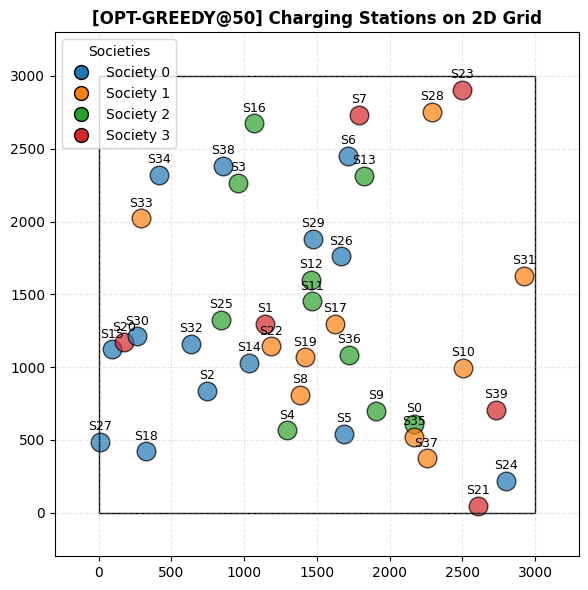

In [19]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

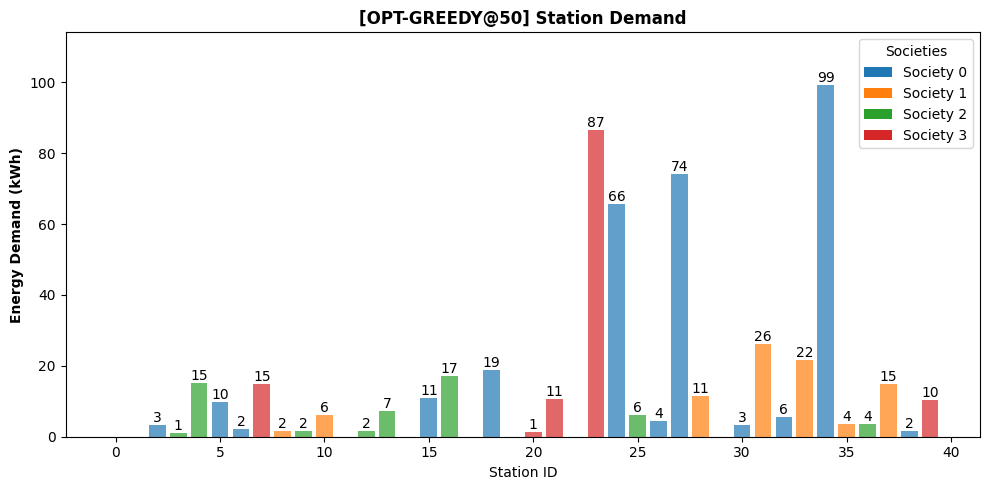

In [20]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

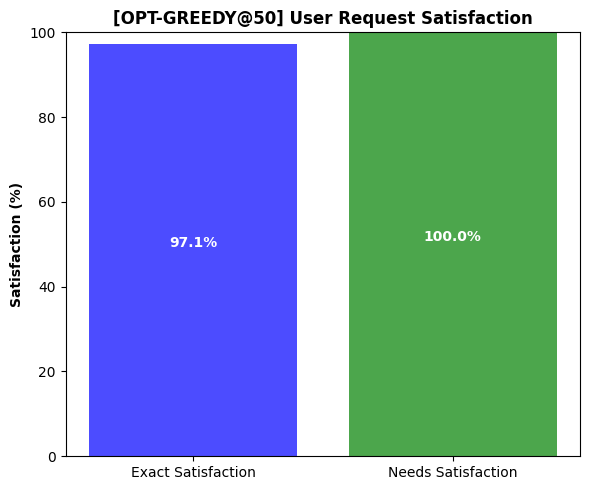

In [21]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

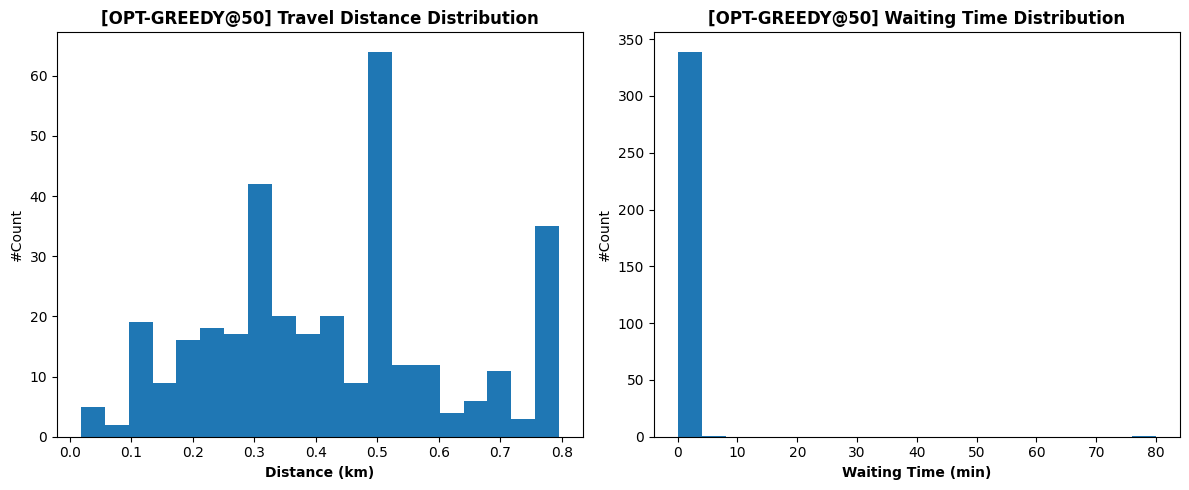

In [22]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

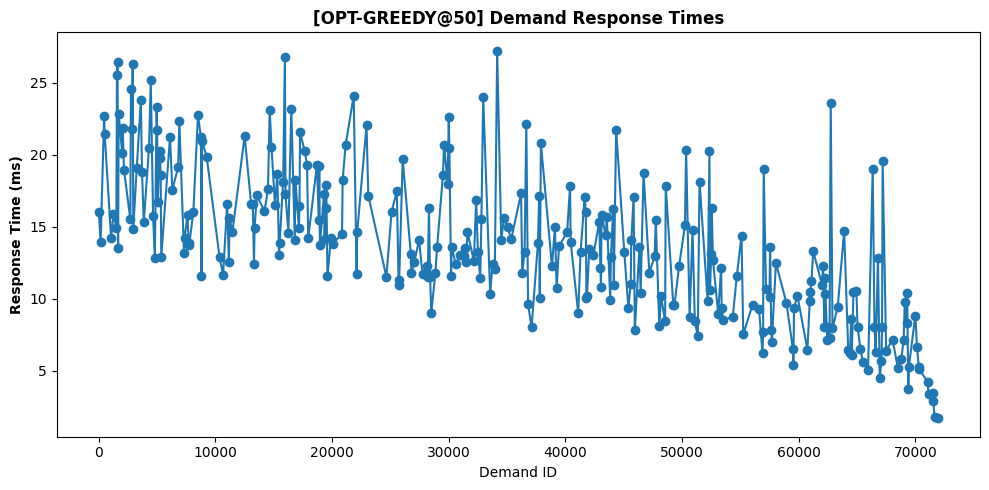

In [23]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

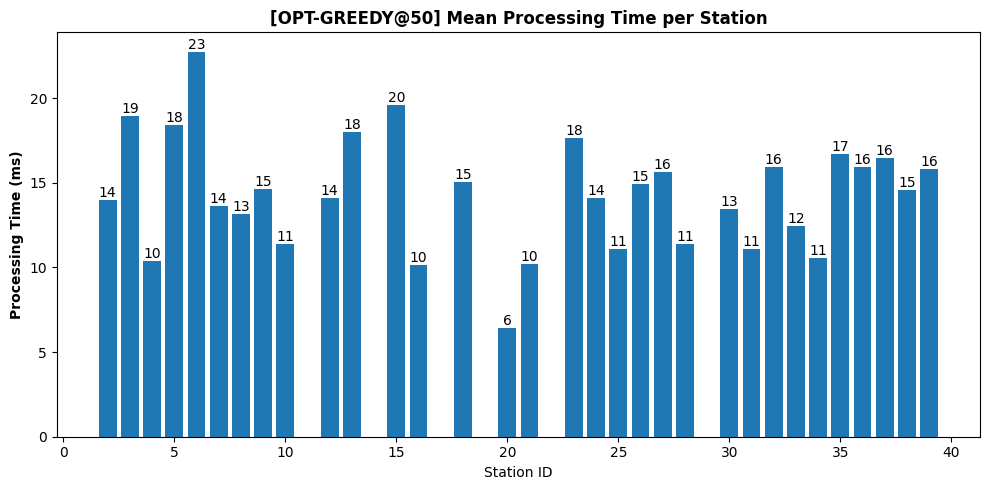

In [24]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [ ]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/50cars


##### *Initialisation*

In [26]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [27]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:05:27.145 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:05:27.470 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:05:27.577 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:05:28.075 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:05:28.894 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:05:29.318 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:05:29.829 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:05:30.259 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:05:30.686 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:05:30.690 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:05:30.938 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [28]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 5.89 kWh
  Station 1: 81.50 kWh
  Station 2: 1.67 kWh
  Station 3: 3.93 kWh
  Station 4: 7.98 kWh
  Station 5: 15.54 kWh
  Station 6: 2.22 kWh
  Station 7: 1.52 kWh
  Station 8: 0.00 kWh
  Station 9: 3.89 kWh
  Station 10: 19.85 kWh
  Station 11: 8.40 kWh
  Station 12: 6.12 kWh
  Station 13: 0.00 kWh
  Station 14: 11.22 kWh
  Station 15: 5.97 kWh
  Station 16: 2.57 kWh
  Station 17: 1.33 kWh
  Station 18: 12.40 kWh
  Station 19: 1.80 kWh
  Station 20: 10.48 kWh
  Station 21: 67.52 kWh
  Station 22: 25.83 kWh
  Station 23: 71.59 kWh
  Station 24: 14.07 kWh
  Station 25: 2.39 kWh
  Station 26: 7.30 kWh
  Station 27: 2.33 kWh
  Station 28: 9.70 kWh
  Station 29: 5.67 kWh
  Station 30: 1.40 kWh
  Station 31: 0.00 kWh
  Station 32: 6.70 kWh
  Station 33: 17.33 kWh
  Station 34: 4.64 kWh
  Station 35: 34.44 kWh
  Station 36: 70.60 kWh
  Station 37: 0.00 kWh
  Station 38: 18.47 kWh
  Station 39: 1.40 kWh

--- User Req

In [29]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

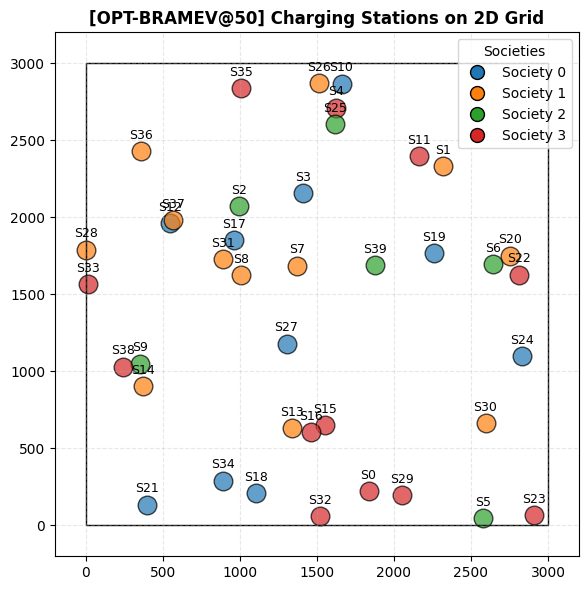

In [30]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

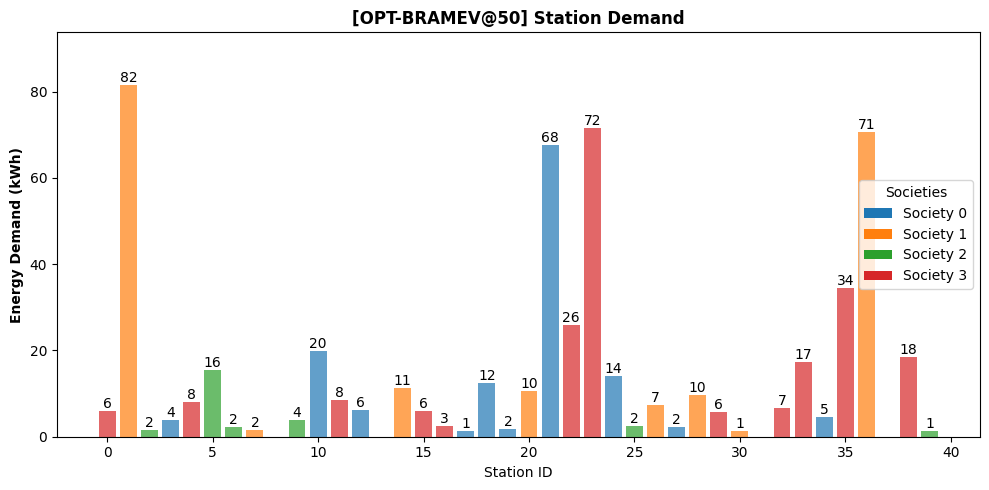

In [31]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

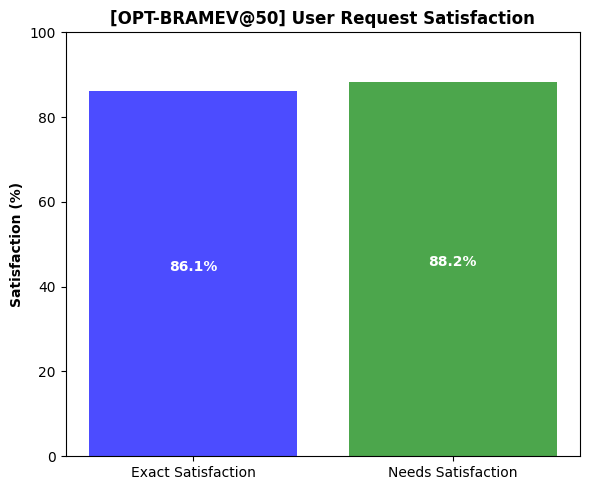

In [32]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

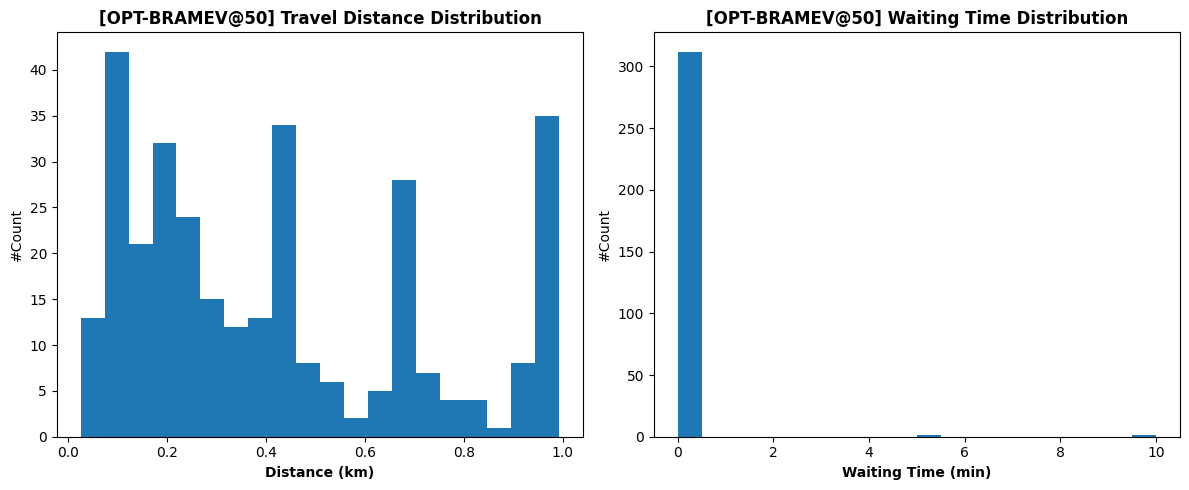

In [33]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

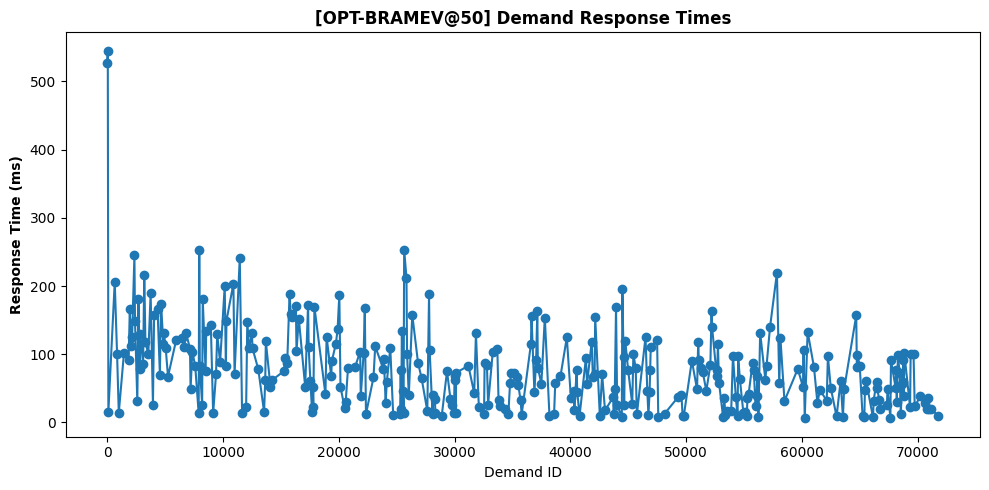

In [34]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

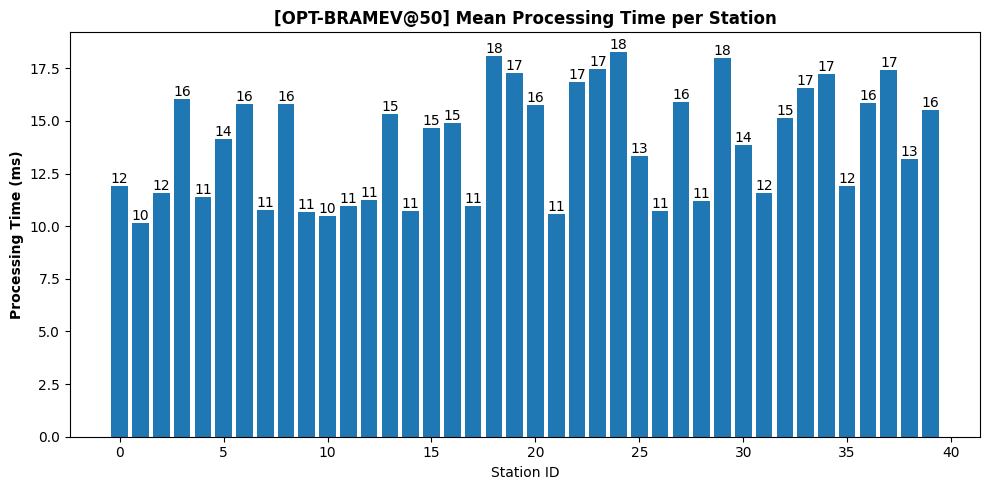

In [35]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

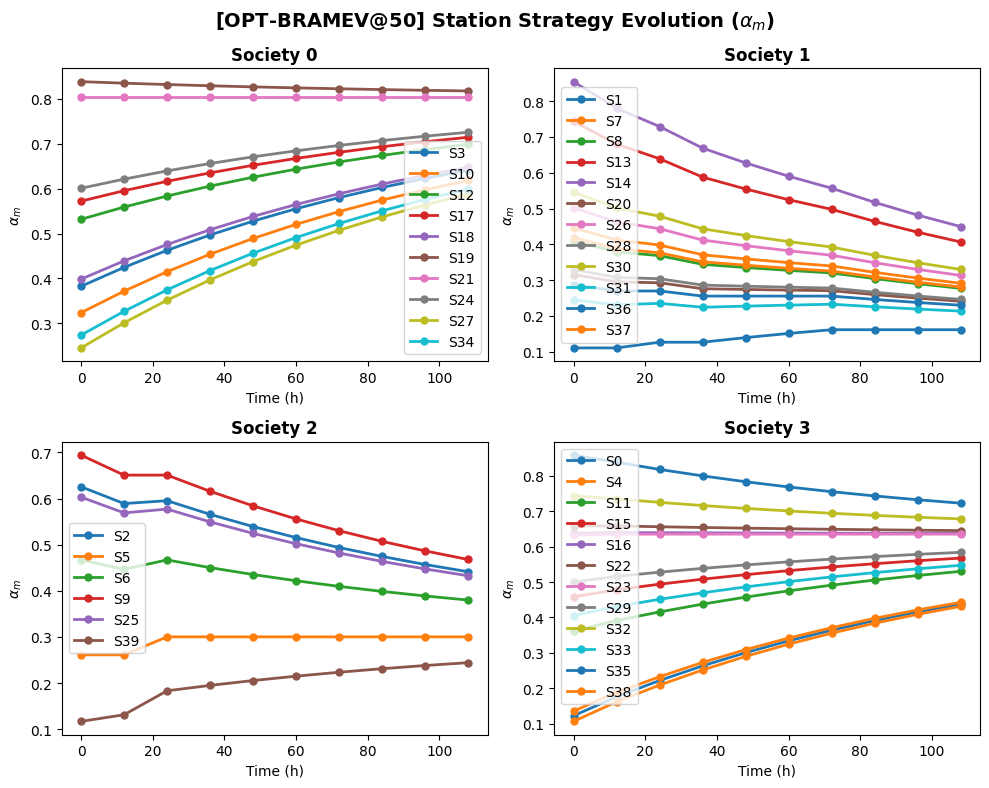

In [36]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [37]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           3  0.053472  0.000000  0.000000  0.000000  0.000000   
1            0          10  0.199306  0.042361  0.000000  0.000000       NaN   
2            0          12  0.079861  0.042361  0.000000  0.000000       NaN   
3            0          17  0.027778  0.000000  0.000000  0.000000       NaN   
4            0          18  0.138889  0.026389  0.000000  0.000000  0.000000   
5            0          19  0.018750  0.000000  0.000000  0.000000  0.000000   
6            0          21  0.527083  0.268750  0.144444  0.044444       NaN   
7            0          24  0.135417  0.042361  0.000000  0.000000  0.000000   
8            0          27  0.024306  0.000000  0.000000  0.000000  0.000000   
9            0          34  0.029861  0.032639  0.000000  0.000000  0.000000   
10           1           1  0.546528  0.363889  0.070833  0.067361       NaN   
11           1           7  0.018056  0.

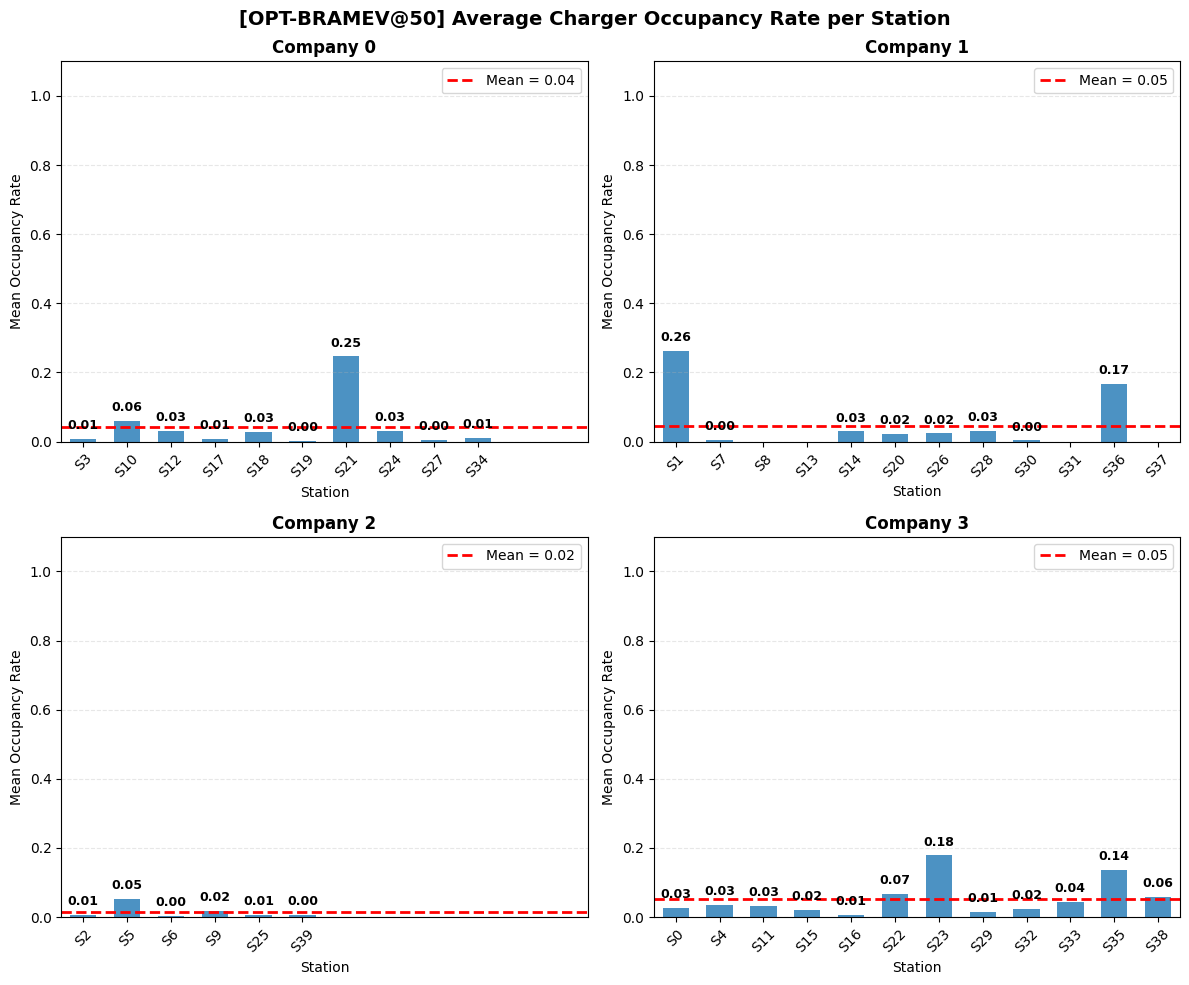

In [38]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

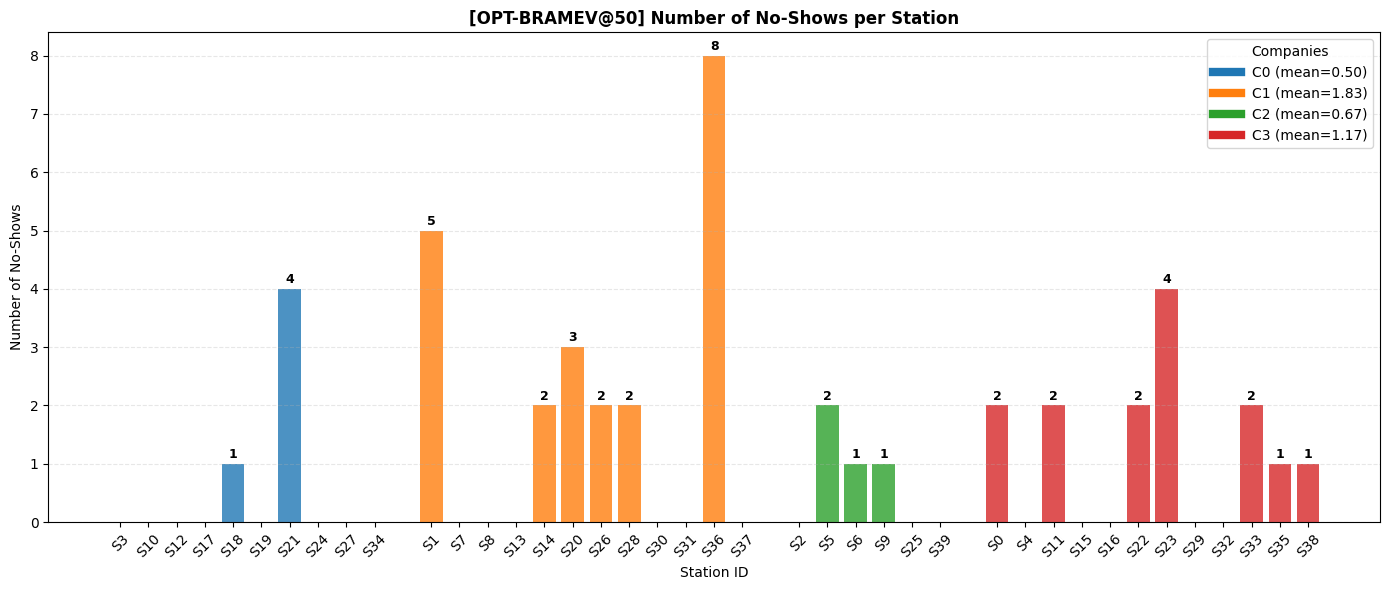

In [39]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [40]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,3,2,2,0,0,0,1.000000,0.000000,0.0,0.0
1,0,10,10,10,0,0,0,1.000000,0.000000,0.0,0.0
2,0,12,4,4,0,0,0,1.000000,0.000000,0.0,0.0
3,0,17,1,1,0,0,0,1.000000,0.000000,0.0,0.0
4,0,18,7,6,1,0,0,0.857143,0.142857,0.0,0.0
5,0,19,1,1,0,0,0,1.000000,0.000000,0.0,0.0
6,0,21,41,36,4,0,0,0.878049,0.097561,0.0,0.0
7,0,24,7,7,0,0,0,1.000000,0.000000,0.0,0.0
8,0,27,1,1,0,0,0,1.000000,0.000000,0.0,0.0
9,0,34,3,3,0,0,0,1.000000,0.000000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [43]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

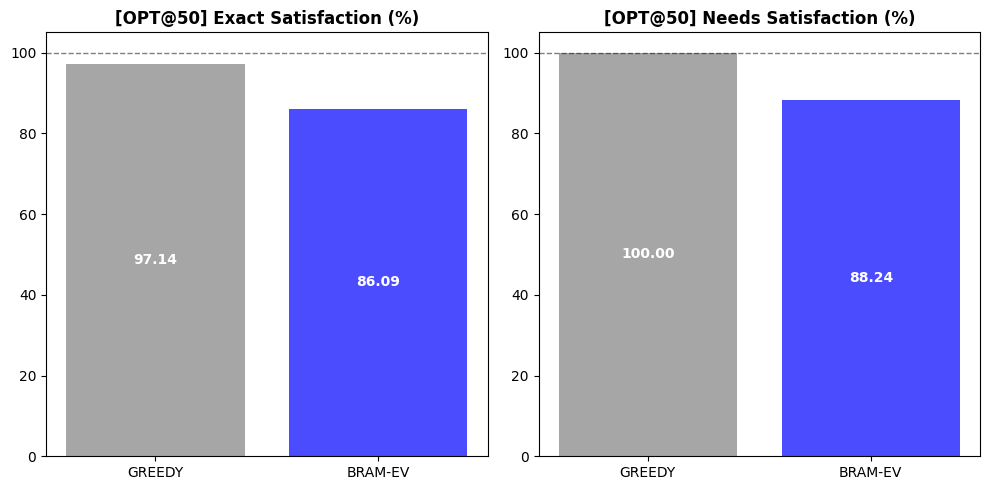

In [44]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

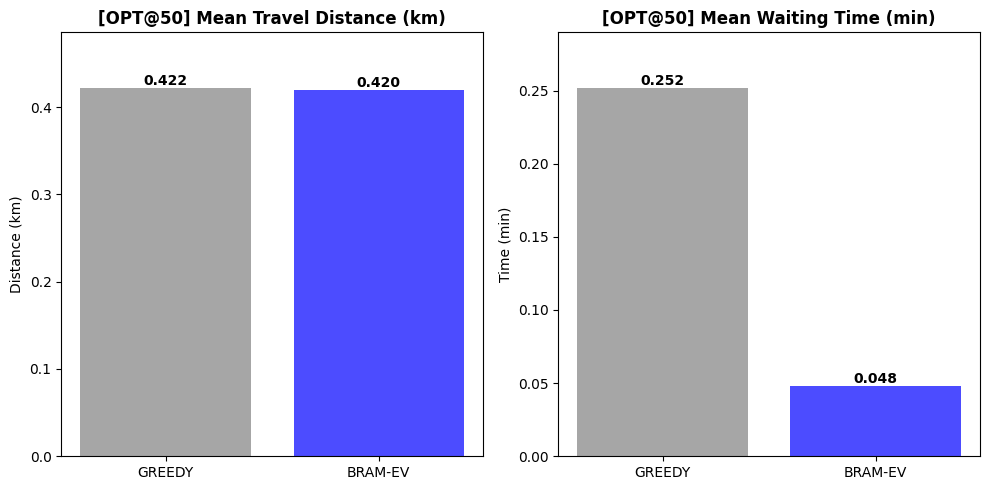

In [45]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

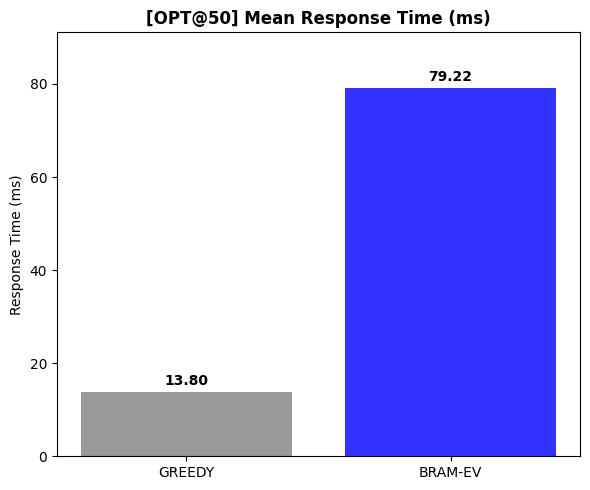

In [46]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [47]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [48]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/100cars


##### *Initialisation*

In [49]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [50]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:07:58.779 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:07:59.000 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:07:59.077 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:07:59.169 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:07:59.390 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:07:59.528 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:07:59.699 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:07:59.805 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:07:59.994 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:08:00.099 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:08:00.226 | IN

##### *Metrics*

In [51]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 68.31 kWh
  Station 1: 33.64 kWh
  Station 2: 3.45 kWh
  Station 3: 4.20 kWh
  Station 4: 192.77 kWh
  Station 5: 161.25 kWh
  Station 6: 5.85 kWh
  Station 7: 7.47 kWh
  Station 8: 128.34 kWh
  Station 9: 3.38 kWh
  Station 10: 0.00 kWh
  Station 11: 13.99 kWh
  Station 12: 3.52 kWh
  Station 13: 14.32 kWh
  Station 14: 7.84 kWh
  Station 15: 7.35 kWh
  Station 16: 11.99 kWh
  Station 17: 1.88 kWh
  Station 18: 134.42 kWh
  Station 19: 5.78 kWh
  Station 20: 4.10 kWh
  Station 21: 19.12 kWh
  Station 22: 2.00 kWh
  Station 23: 15.57 kWh
  Station 24: 30.05 kWh
  Station 25: 17.08 kWh
  Station 26: 8.40 kWh
  Station 27: 32.10 kWh
  Station 28: 0.00 kWh
  Station 29: 57.19 kWh
  Station 30: 29.24 kWh
  Station 31: 26.60 kWh
  Station 32: 3.00 kWh
  Station 33: 6.60 kWh
  Station 34: 6.30 kWh
  Station 35: 4.62 kWh
  Station 36: 22.13 kWh
  Station 37: 5.67 kWh
  Station 38: 1.53 kWh
  Station 39: 6.90 kWh

--- 

In [52]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

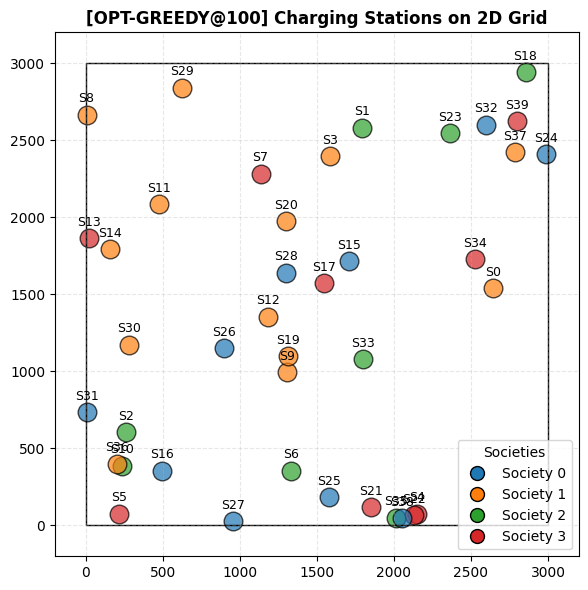

In [53]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

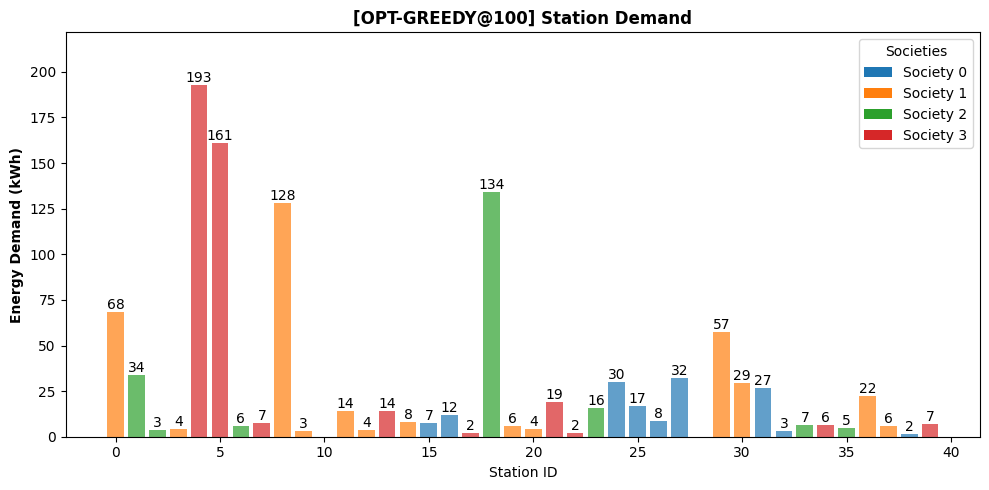

In [54]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

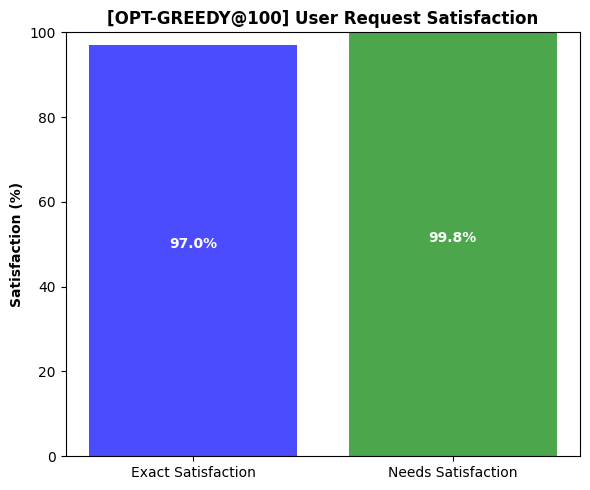

In [55]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

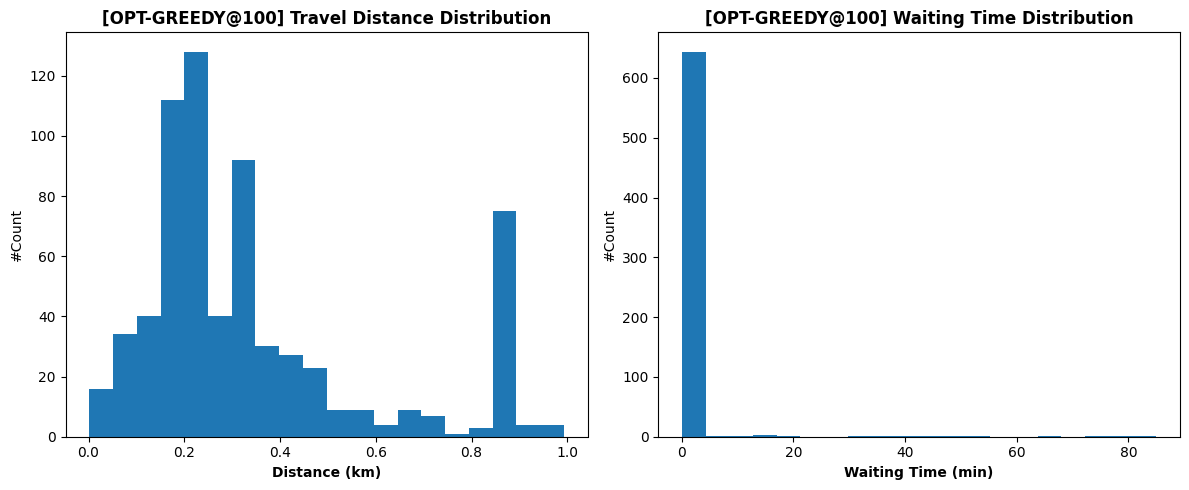

In [56]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

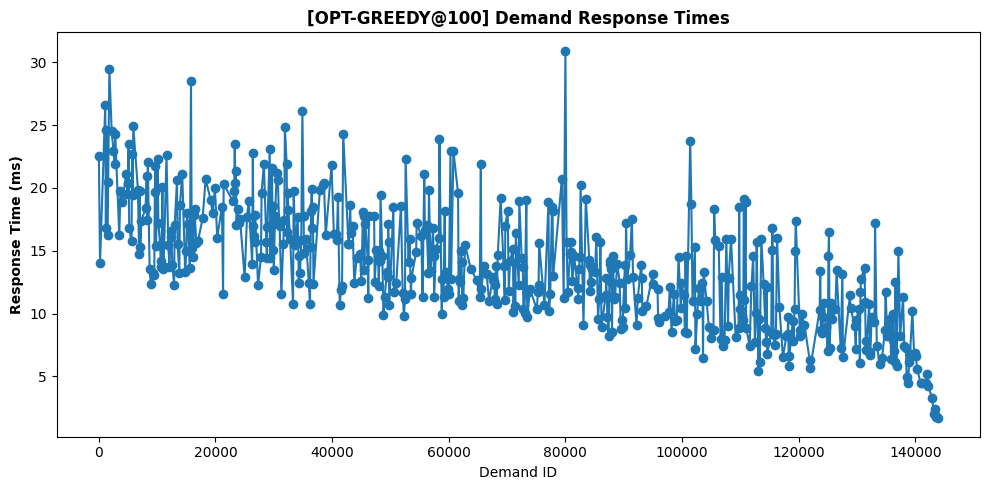

In [57]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

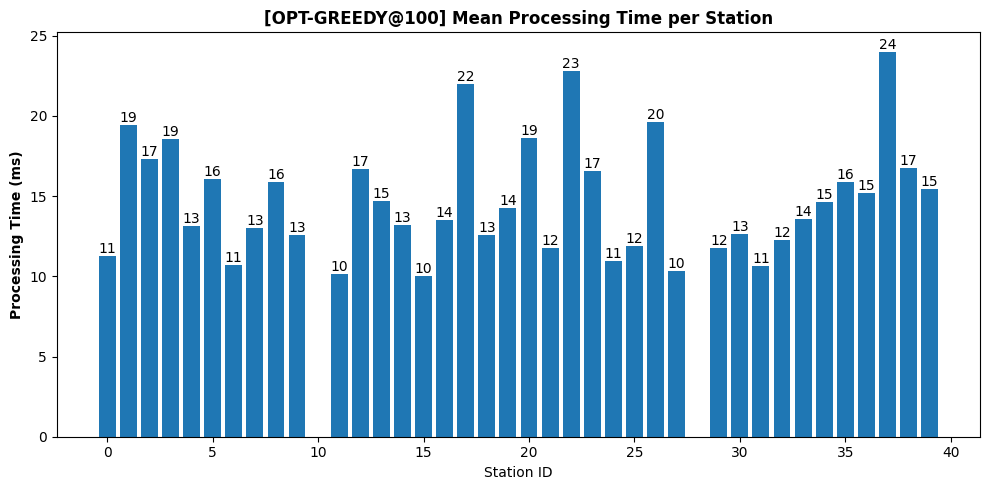

In [58]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [ ]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/100cars


##### *Initialisation*

In [60]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [61]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:08:11.135 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:08:12.295 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:08:12.851 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:08:13.294 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:08:13.726 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:08:14.699 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:08:15.331 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:08:15.601 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:08:16.157 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:08:16.617 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:08:17.440 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [62]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 1.97 kWh
  Station 1: 28.89 kWh
  Station 2: 1.93 kWh
  Station 3: 0.00 kWh
  Station 4: 27.02 kWh
  Station 5: 24.18 kWh
  Station 6: 11.53 kWh
  Station 7: 5.02 kWh
  Station 8: 43.46 kWh
  Station 9: 30.43 kWh
  Station 10: 23.46 kWh
  Station 11: 7.24 kWh
  Station 12: 9.38 kWh
  Station 13: 39.25 kWh
  Station 14: 93.02 kWh
  Station 15: 31.38 kWh
  Station 16: 5.25 kWh
  Station 17: 47.38 kWh
  Station 18: 0.00 kWh
  Station 19: 146.68 kWh
  Station 20: 19.92 kWh
  Station 21: 33.52 kWh
  Station 22: 0.00 kWh
  Station 23: 6.04 kWh
  Station 24: 19.14 kWh
  Station 25: 2.12 kWh
  Station 26: 24.09 kWh
  Station 27: 8.59 kWh
  Station 28: 1.65 kWh
  Station 29: 38.87 kWh
  Station 30: 3.63 kWh
  Station 31: 129.74 kWh
  Station 32: 3.92 kWh
  Station 33: 6.66 kWh
  Station 34: 55.58 kWh
  Station 35: 142.18 kWh
  Station 36: 3.62 kWh
  Station 37: 12.68 kWh
  Station 38: 5.97 kWh
  Station 39: 10.70 kWh

-

In [63]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

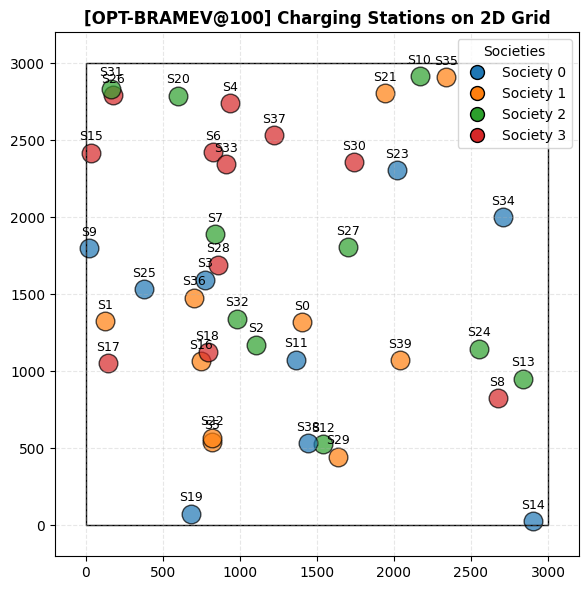

In [64]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

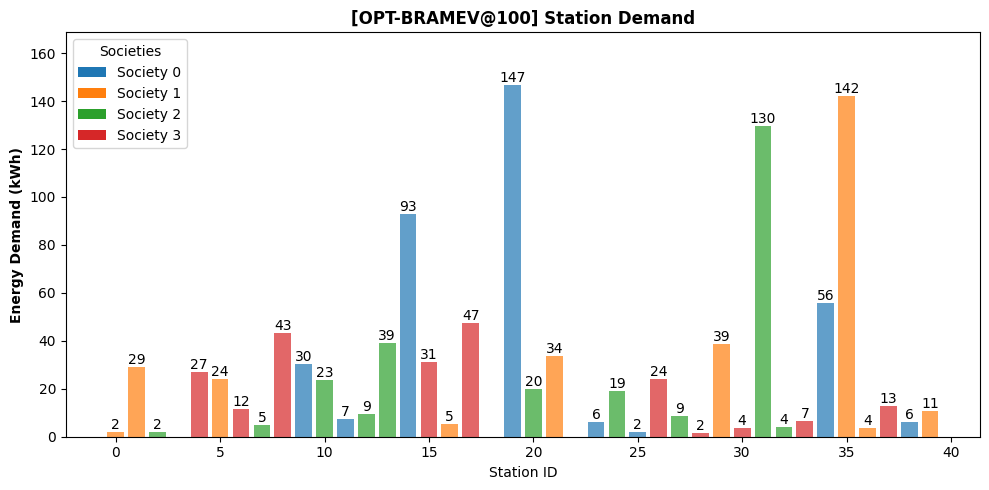

In [65]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

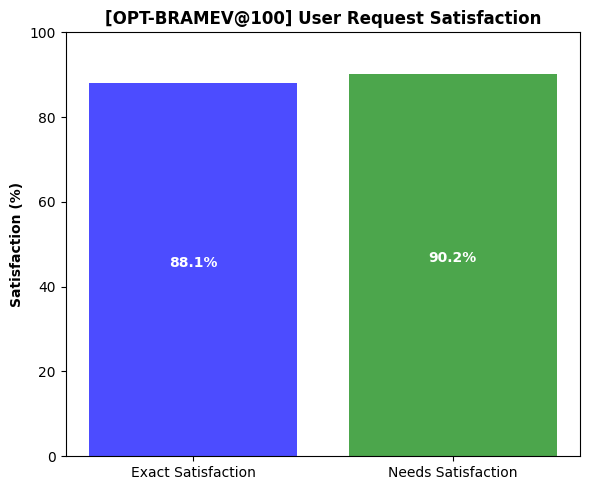

In [66]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

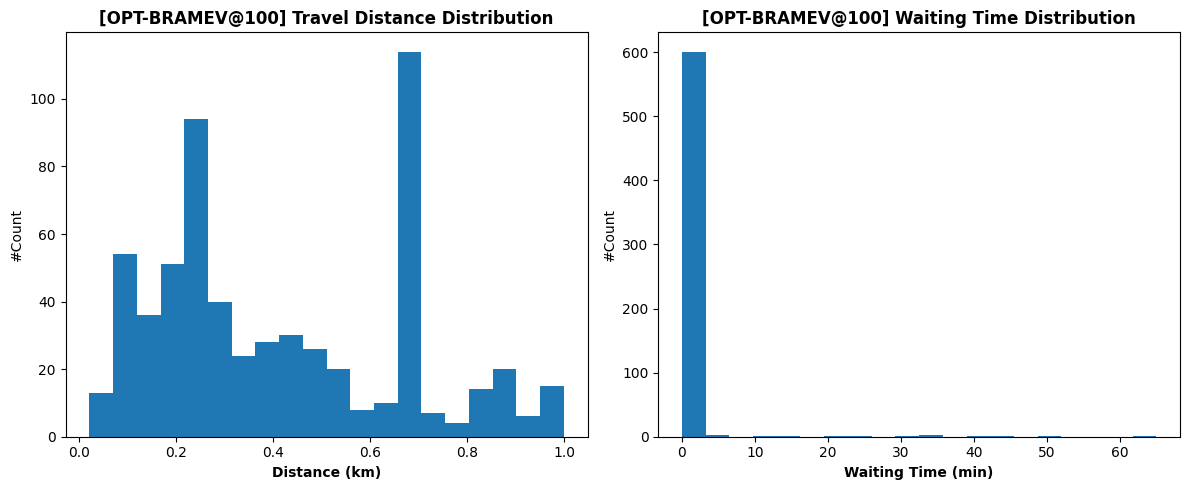

In [67]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

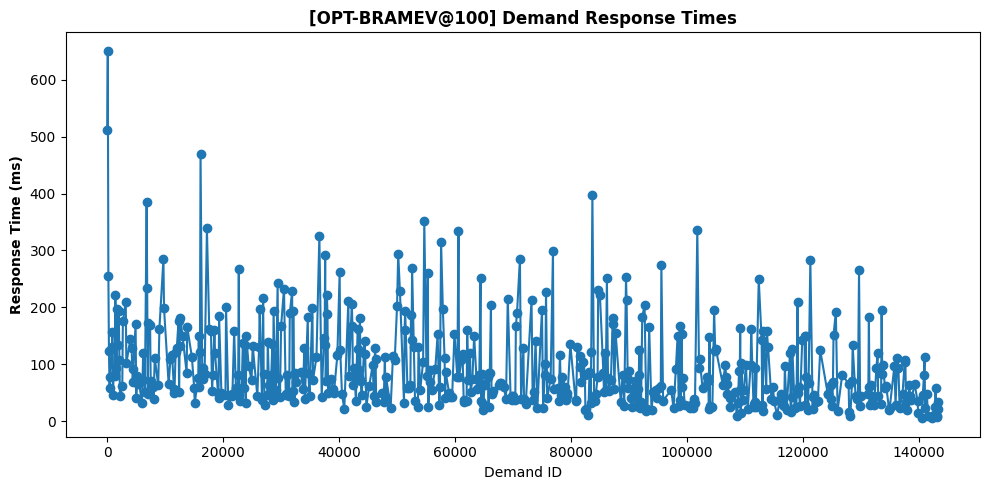

In [68]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

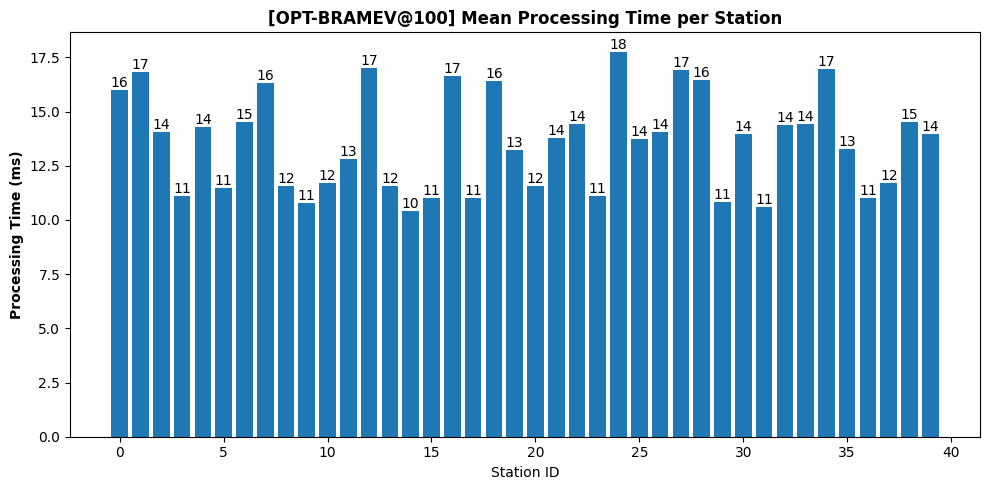

In [69]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

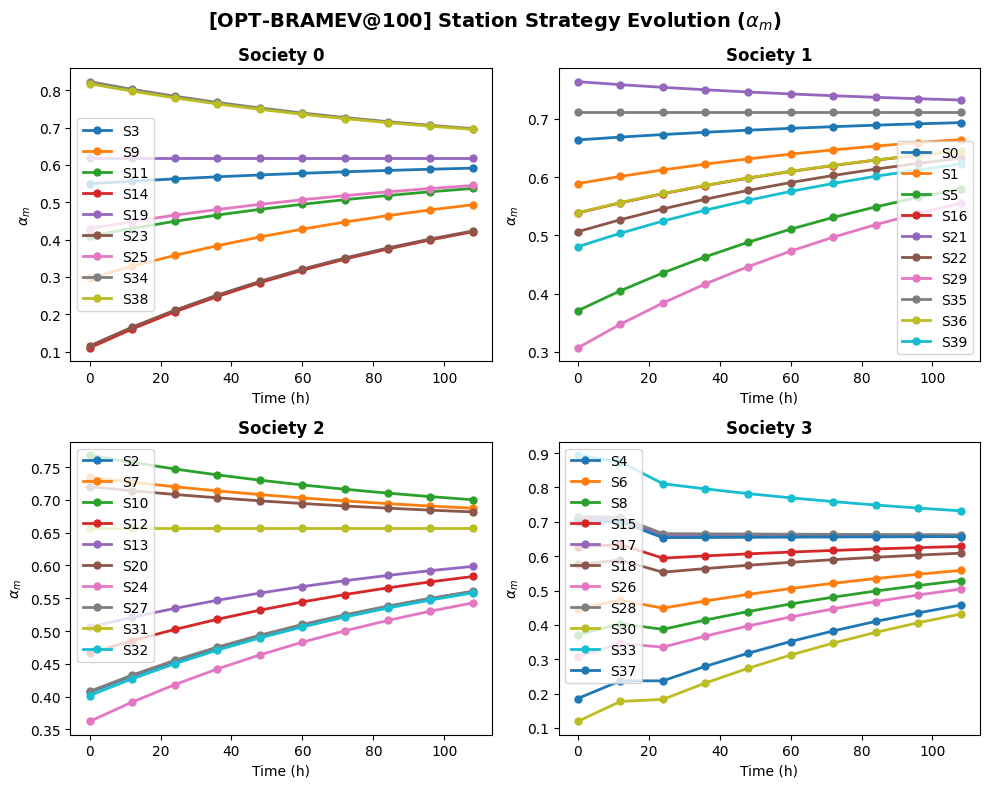

In [70]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [71]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           3  0.000000  0.000000  0.000000  0.000000       NaN   
1            0           9  0.263889  0.164583  0.000000  0.000000       NaN   
2            0          11  0.102083  0.000000  0.000000  0.000000  0.000000   
3            0          14  0.531250  0.409028  0.240972  0.092361       NaN   
4            0          19  0.740278  0.573611  0.318056  0.261111  0.367361   
5            0          23  0.100694  0.000000  0.000000  0.000000       NaN   
6            0          25  0.035417  0.000000  0.000000  0.000000  0.000000   
7            0          34  0.382639  0.222222  0.062500  0.000000  0.028472   
8            0          38  0.085417  0.000000  0.000000  0.000000  0.000000   
9            1           0  0.048611  0.000000  0.000000  0.000000  0.000000   
10           1           1  0.297222  0.030556  0.026389  0.000000  0.000000   
11           1           5  0.265278  0.

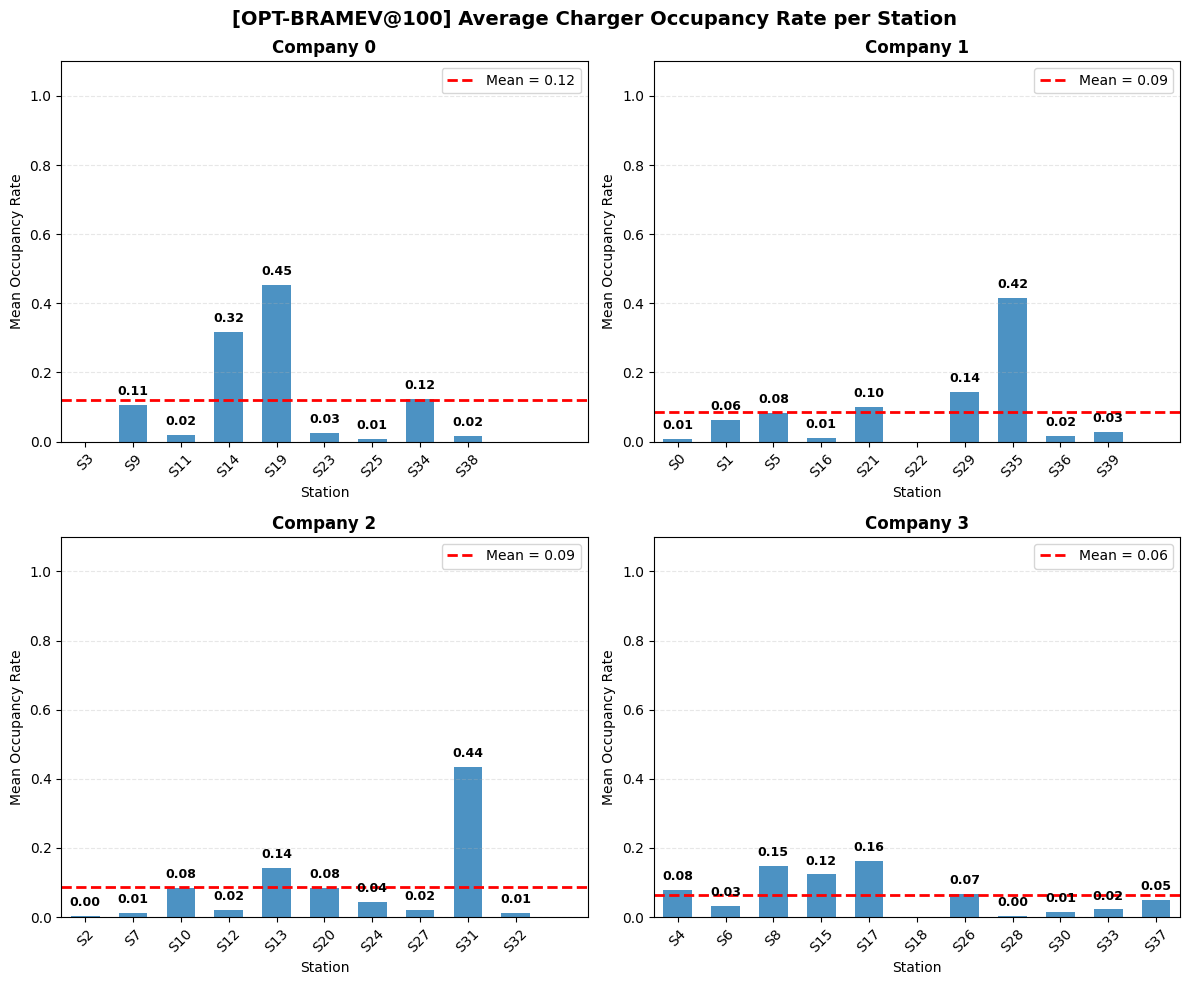

In [72]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

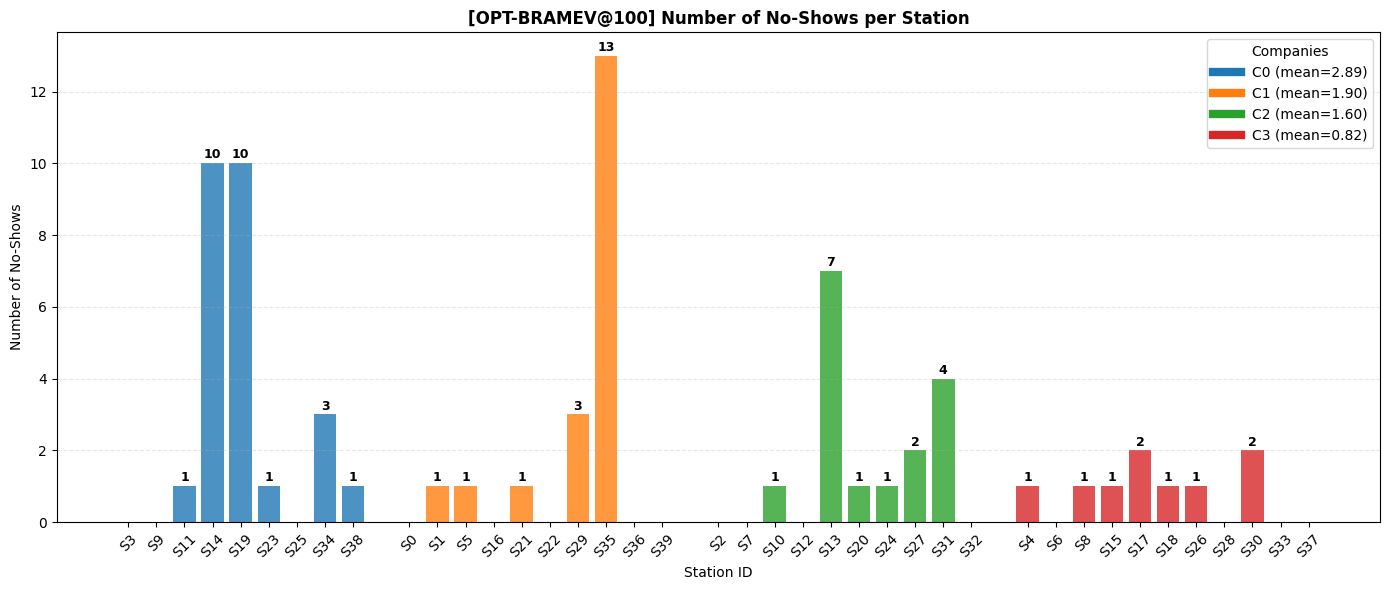

In [73]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [74]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,3,0,0,0,0,0,NaN,NaN,NaN,NaN
1,0,9,18,18,0,0,0,1.000000,0.000000,0.0,0.0
2,0,11,6,5,1,0,0,0.833333,0.166667,0.0,0.0
3,0,14,64,53,10,0,0,0.828125,0.156250,0.0,0.0
4,0,19,94,84,10,0,0,0.893617,0.106383,0.0,0.0
5,0,23,4,3,1,0,0,0.750000,0.250000,0.0,0.0
6,0,25,1,1,0,0,0,1.000000,0.000000,0.0,0.0
7,0,34,36,33,3,0,0,0.916667,0.083333,0.0,0.0
8,0,38,5,4,1,0,0,0.800000,0.200000,0.0,0.0
9,1,0,2,1,0,0,0,0.500000,0.000000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [75]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

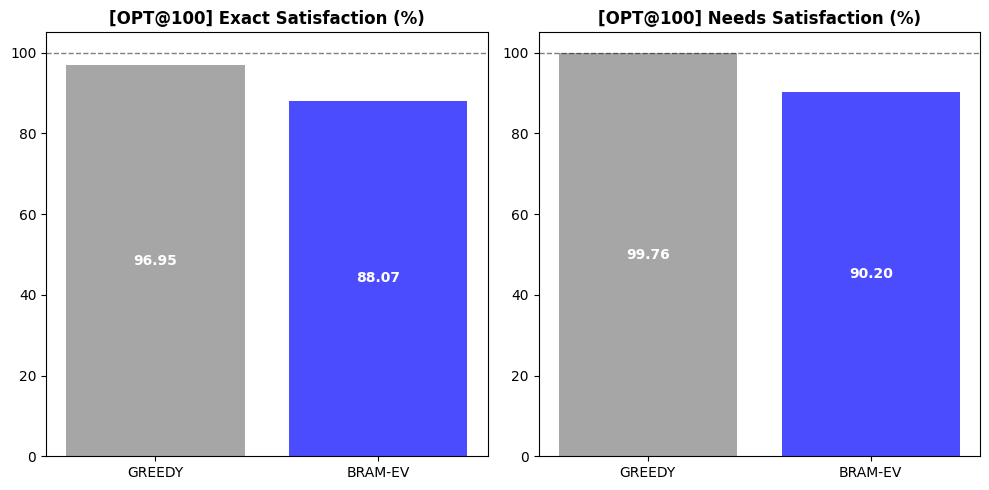

In [76]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

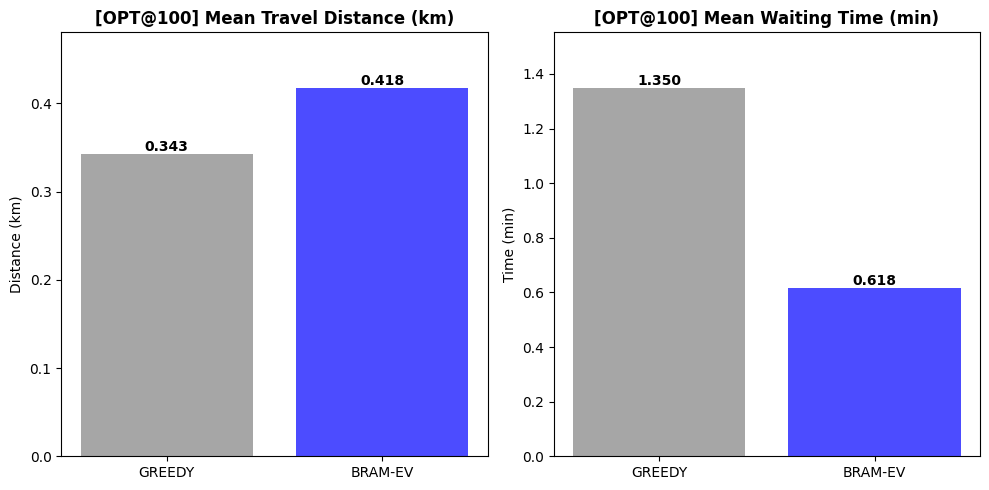

In [77]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

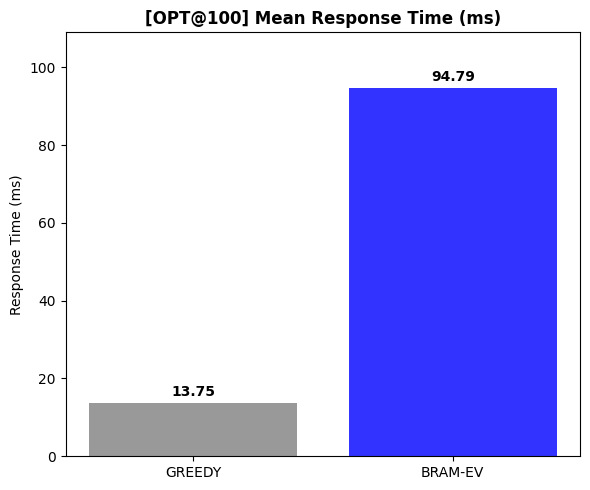

In [78]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [79]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [80]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/150cars


##### *Initialisation*

In [81]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [82]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:09:04.233 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:09:04.519 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:09:04.852 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:09:04.942 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:09:05.283 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:09:05.425 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:09:05.624 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:09:05.751 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:09:05.881 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:09:06.181 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:09:06.310 | IN

##### *Metrics*

In [83]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 49.29 kWh
  Station 1: 38.94 kWh
  Station 2: 6.60 kWh
  Station 3: 4.78 kWh
  Station 4: 2.47 kWh
  Station 5: 59.77 kWh
  Station 6: 6.43 kWh
  Station 7: 52.12 kWh
  Station 8: 7.08 kWh
  Station 9: 57.91 kWh
  Station 10: 7.62 kWh
  Station 11: 59.52 kWh
  Station 12: 195.98 kWh
  Station 13: 75.65 kWh
  Station 14: 6.72 kWh
  Station 15: 3.67 kWh
  Station 16: 0.00 kWh
  Station 17: 0.00 kWh
  Station 18: 3.40 kWh
  Station 19: 8.37 kWh
  Station 20: 259.51 kWh
  Station 21: 29.73 kWh
  Station 22: 0.00 kWh
  Station 23: 237.88 kWh
  Station 24: 1.47 kWh
  Station 25: 7.17 kWh
  Station 26: 5.34 kWh
  Station 27: 10.44 kWh
  Station 28: 7.28 kWh
  Station 29: 9.59 kWh
  Station 30: 22.32 kWh
  Station 31: 8.69 kWh
  Station 32: 6.05 kWh
  Station 33: 2.47 kWh
  Station 34: 63.11 kWh
  Station 35: 60.73 kWh
  Station 36: 3.21 kWh
  Station 37: 46.23 kWh
  Station 38: 4.75 kWh
  Station 39: 220.02 kWh

--- U

In [84]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

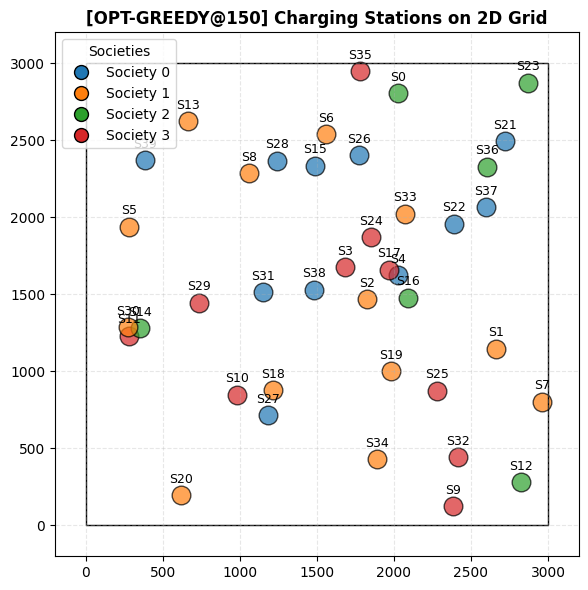

In [85]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

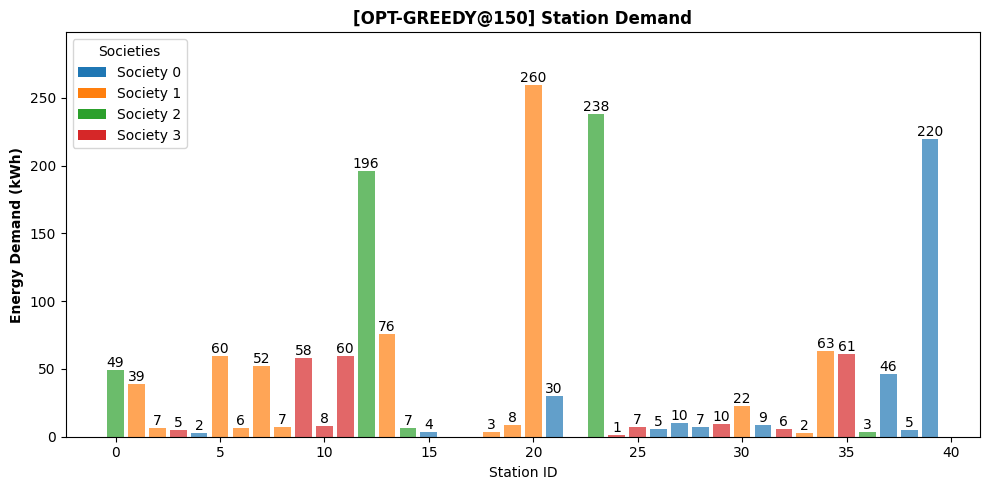

In [86]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

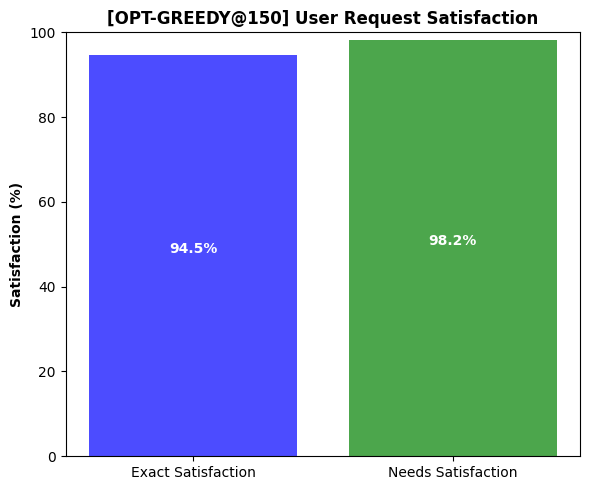

In [87]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

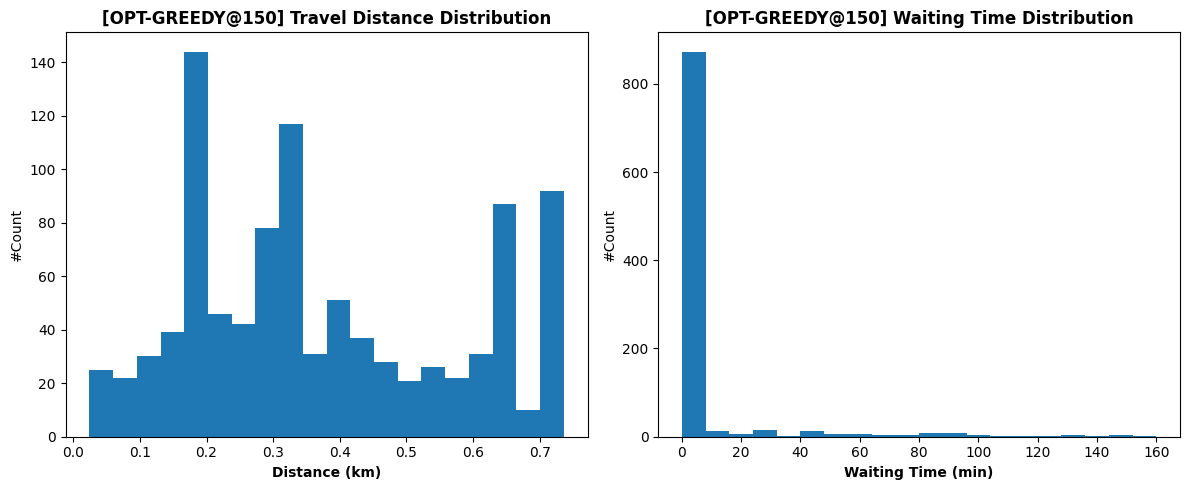

In [88]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

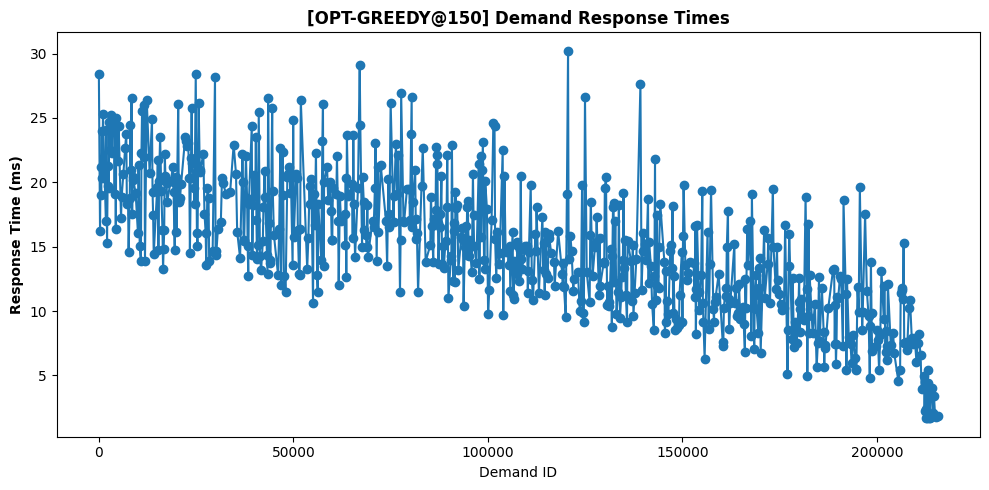

In [89]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

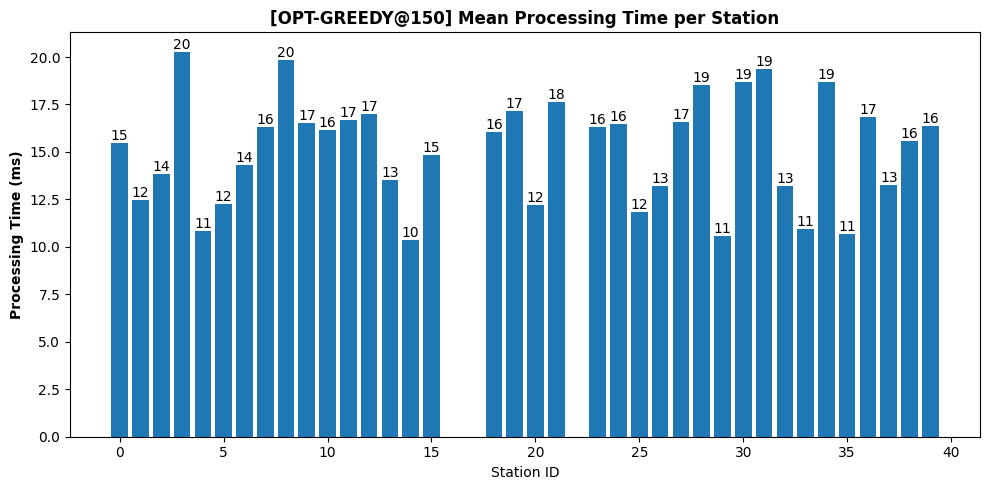

In [90]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [ ]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/150cars


##### *Initialisation*

In [92]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [93]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:09:23.835 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:09:24.460 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:09:25.547 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:09:26.275 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:09:28.232 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:09:28.919 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:09:30.021 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:09:30.465 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:09:32.088 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:09:33.263 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:09:33.924 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [94]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 42.91 kWh
  Station 1: 82.41 kWh
  Station 2: 9.80 kWh
  Station 3: 5.08 kWh
  Station 4: 22.84 kWh
  Station 5: 71.97 kWh
  Station 6: 8.14 kWh
  Station 7: 158.47 kWh
  Station 8: 10.06 kWh
  Station 9: 67.13 kWh
  Station 10: 17.43 kWh
  Station 11: 4.26 kWh
  Station 12: 34.62 kWh
  Station 13: 33.97 kWh
  Station 14: 151.75 kWh
  Station 15: 10.89 kWh
  Station 16: 14.12 kWh
  Station 17: 12.67 kWh
  Station 18: 20.35 kWh
  Station 19: 8.70 kWh
  Station 20: 171.16 kWh
  Station 21: 42.55 kWh
  Station 22: 5.15 kWh
  Station 23: 4.15 kWh
  Station 24: 6.53 kWh
  Station 25: 5.83 kWh
  Station 26: 10.27 kWh
  Station 27: 8.68 kWh
  Station 28: 15.99 kWh
  Station 29: 190.78 kWh
  Station 30: 0.00 kWh
  Station 31: 68.23 kWh
  Station 32: 21.42 kWh
  Station 33: 71.34 kWh
  Station 34: 5.58 kWh
  Station 35: 59.55 kWh
  Station 36: 40.62 kWh
  Station 37: 13.65 kWh
  Station 38: 34.82 kWh
  Station 39: 85.82

In [95]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

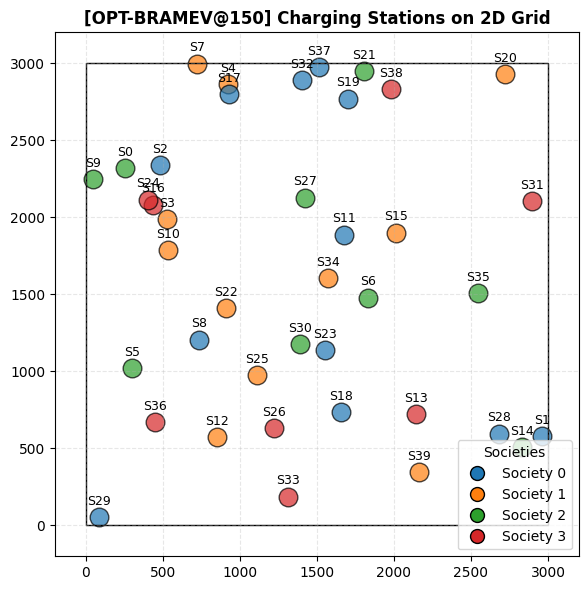

In [96]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

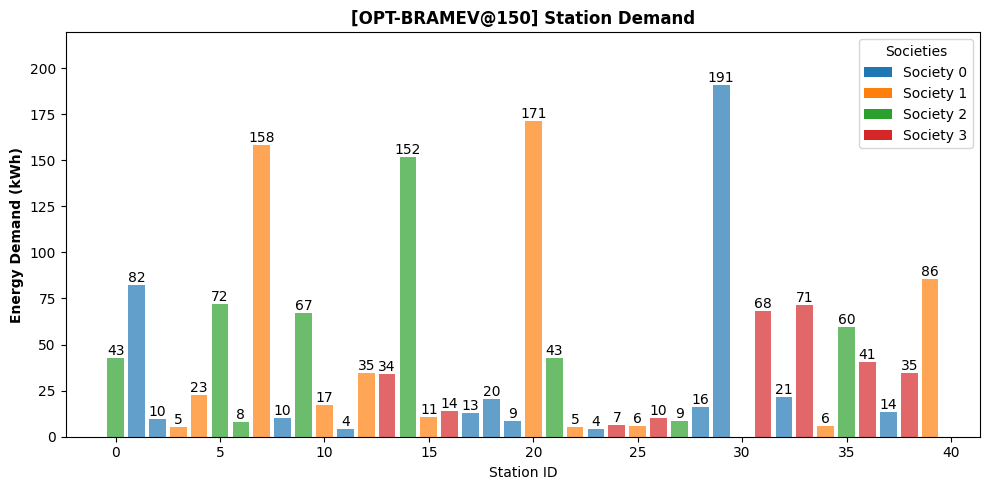

In [97]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

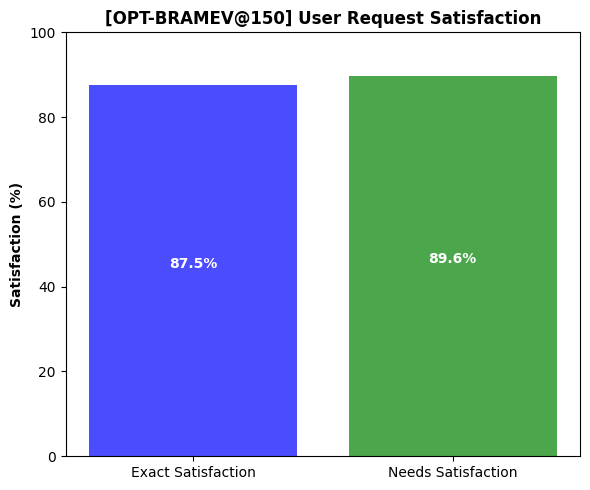

In [98]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

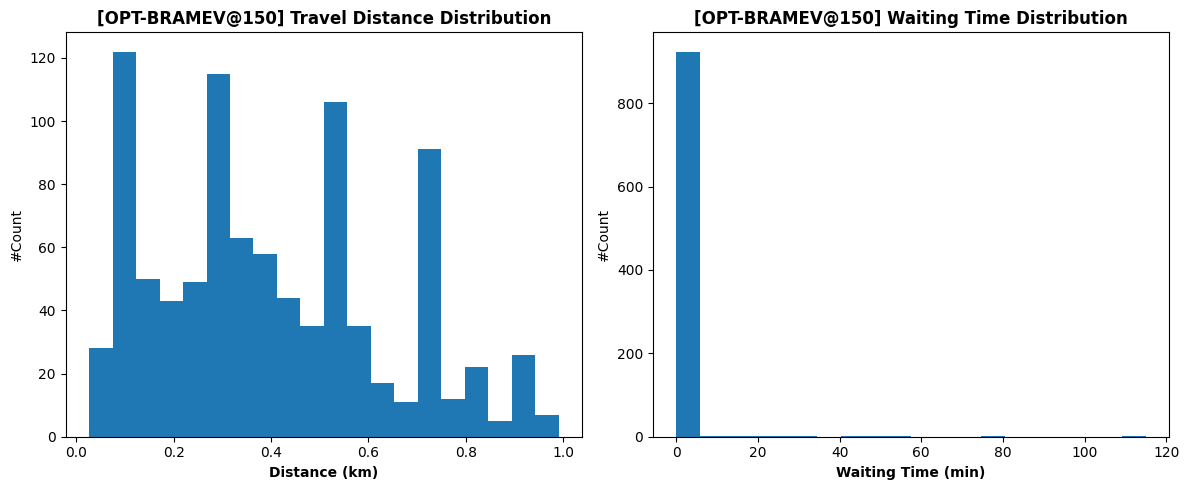

In [99]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

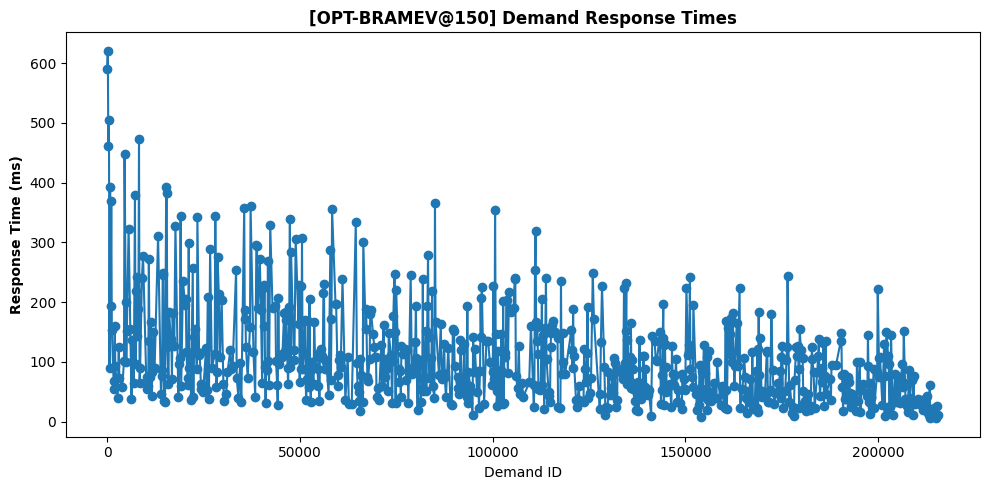

In [100]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

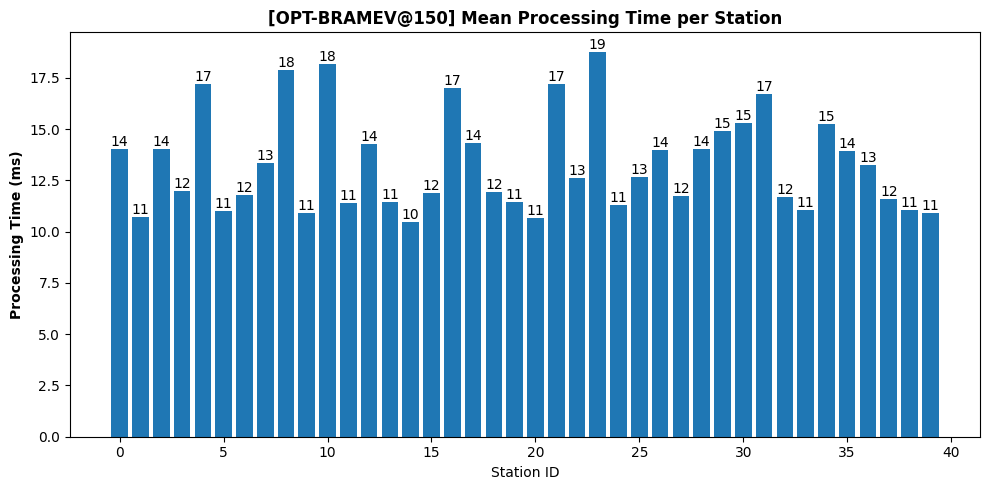

In [101]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

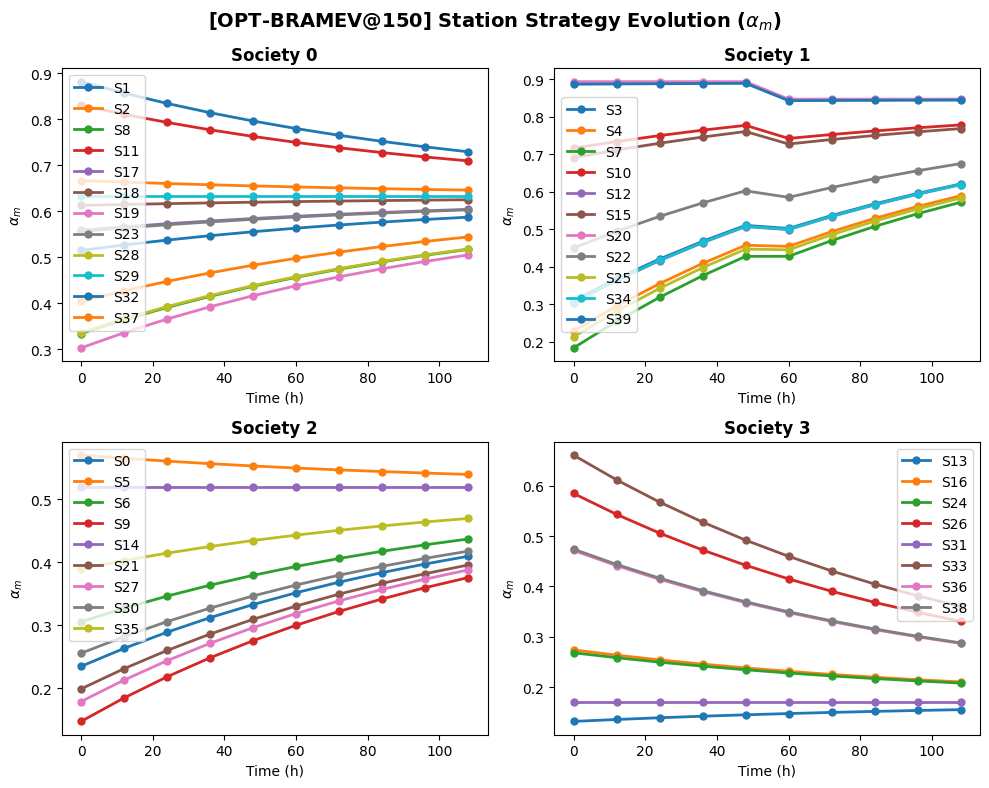

In [102]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [103]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.497917  0.369444  0.108333  0.201389       NaN   
1            0           2  0.165278  0.000000  0.000000  0.000000  0.000000   
2            0           8  0.123611  0.000000  0.000000  0.000000  0.000000   
3            0          11  0.077083  0.000000  0.000000  0.000000       NaN   
4            0          17  0.147917  0.000000  0.000000  0.000000  0.000000   
5            0          18  0.247917  0.047917  0.000000  0.000000       NaN   
6            0          19  0.124306  0.016667  0.000000  0.000000       NaN   
7            0          23  0.065278  0.000000  0.000000  0.000000  0.000000   
8            0          28  0.156944  0.045139  0.000000  0.000000  0.000000   
9            0          29  0.759722  0.700694  0.433333  0.261111  0.287500   
10           0          32  0.238889  0.062500  0.000000  0.000000       NaN   
11           0          37  0.188194  0.

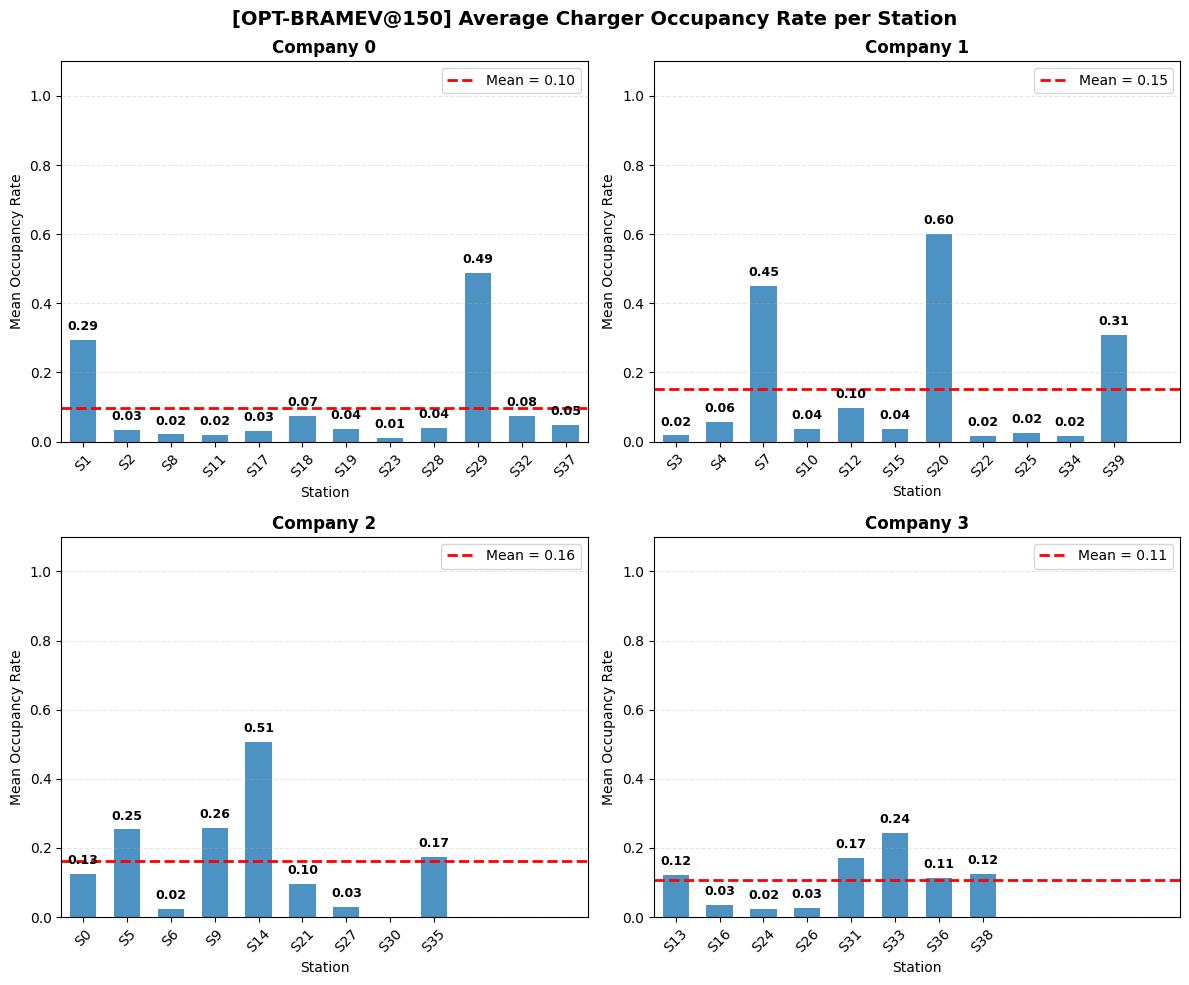

In [104]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

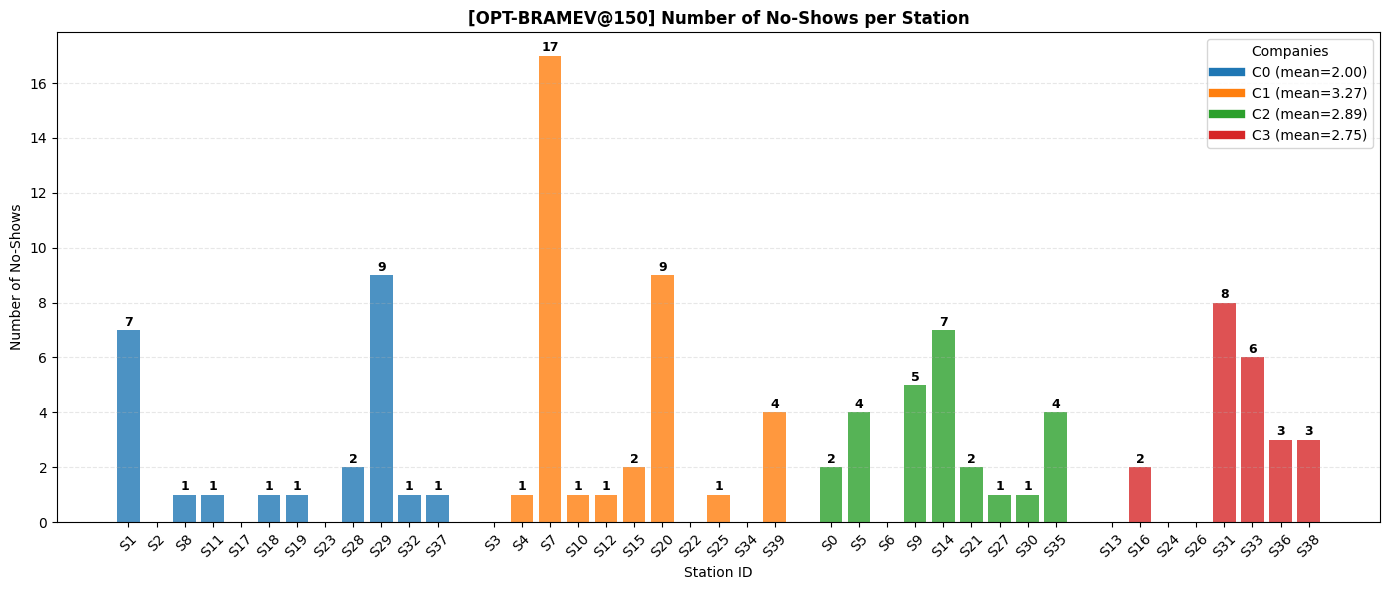

In [105]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [106]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,51,44,7,0,0,0.862745,0.137255,0.0,0.0
1,0,2,6,6,0,0,0,1.000000,0.000000,0.0,0.0
2,0,8,8,7,1,0,0,0.875000,0.125000,0.0,0.0
3,0,11,3,2,1,0,0,0.666667,0.333333,0.0,0.0
4,0,17,8,8,0,0,0,1.000000,0.000000,0.0,0.0
5,0,18,12,11,1,0,0,0.916667,0.083333,0.0,0.0
6,0,19,6,5,1,0,0,0.833333,0.166667,0.0,0.0
7,0,23,3,3,0,0,0,1.000000,0.000000,0.0,0.0
8,0,28,11,9,2,0,0,0.818182,0.181818,0.0,0.0
9,0,29,118,109,9,0,0,0.923729,0.076271,0.0,0.0


#### **COMPARISON**

##### *Params*

In [107]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

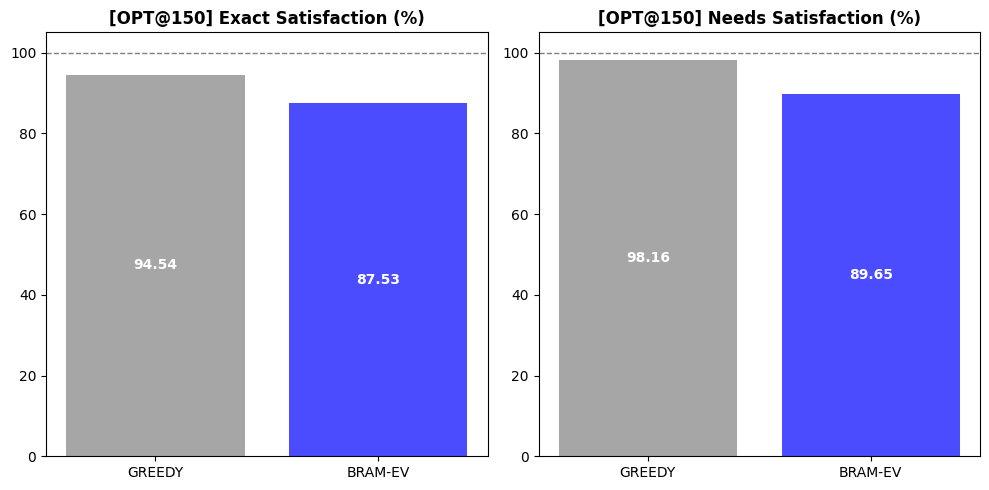

In [108]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

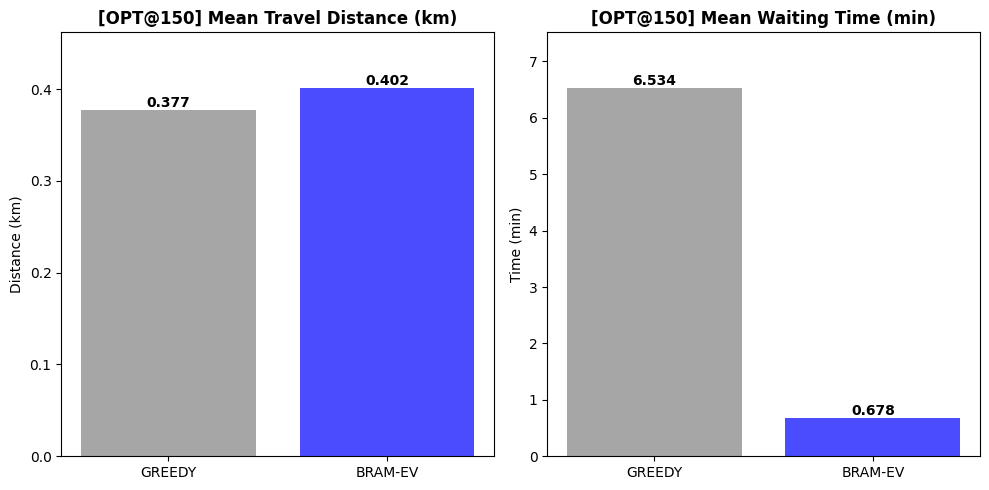

In [109]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

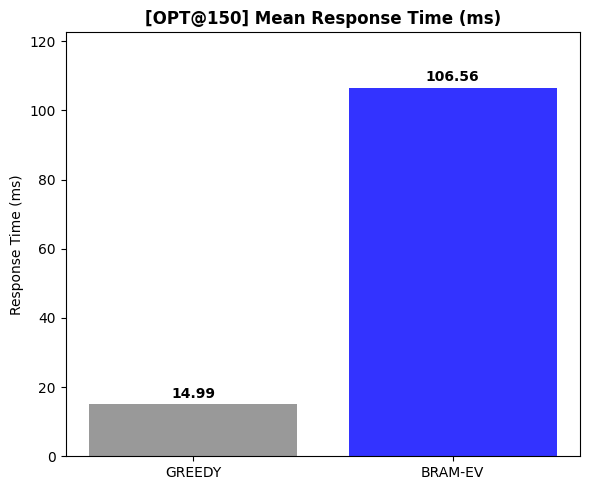

In [110]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [111]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [112]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/200cars


##### *Initialisation*

In [113]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [114]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:10:45.310 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:10:45.527 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:10:45.865 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:10:46.081 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:10:46.195 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:10:46.486 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:10:46.757 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:10:47.038 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:10:47.283 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:10:47.528 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:10:47.842 | IN

##### *Metrics*

In [115]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 149.28 kWh
  Station 1: 12.00 kWh
  Station 2: 54.48 kWh
  Station 3: 10.61 kWh
  Station 4: 304.28 kWh
  Station 5: 57.58 kWh
  Station 6: 7.67 kWh
  Station 7: 6.38 kWh
  Station 8: 299.96 kWh
  Station 9: 4.98 kWh
  Station 10: 2.53 kWh
  Station 11: 11.53 kWh
  Station 12: 4.83 kWh
  Station 13: 87.25 kWh
  Station 14: 50.69 kWh
  Station 15: 12.24 kWh
  Station 16: 336.36 kWh
  Station 17: 30.23 kWh
  Station 18: 7.38 kWh
  Station 19: 14.22 kWh
  Station 20: 227.04 kWh
  Station 21: 71.59 kWh
  Station 22: 2.58 kWh
  Station 23: 76.45 kWh
  Station 24: 73.83 kWh
  Station 25: 5.47 kWh
  Station 26: 0.00 kWh
  Station 27: 7.85 kWh
  Station 28: 2.58 kWh
  Station 29: 13.52 kWh
  Station 30: 9.45 kWh
  Station 31: 5.87 kWh
  Station 32: 46.53 kWh
  Station 33: 8.99 kWh
  Station 34: 21.23 kWh
  Station 35: 5.36 kWh
  Station 36: 6.25 kWh
  Station 37: 52.23 kWh
  Station 38: 9.97 kWh
  Station 39: 45.95 kWh

In [116]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

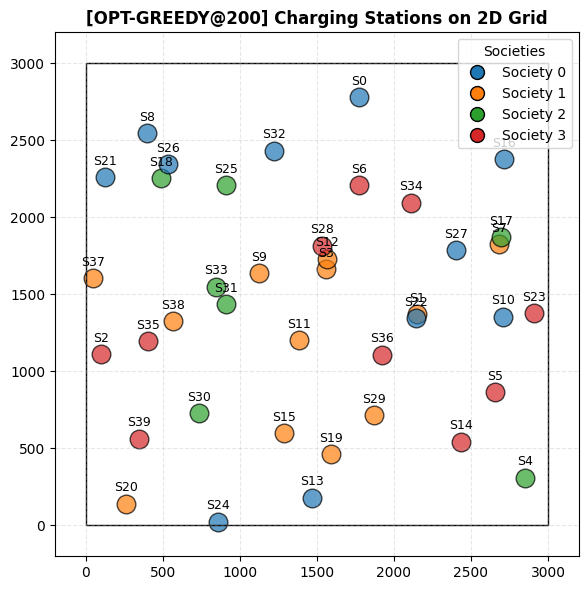

In [117]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

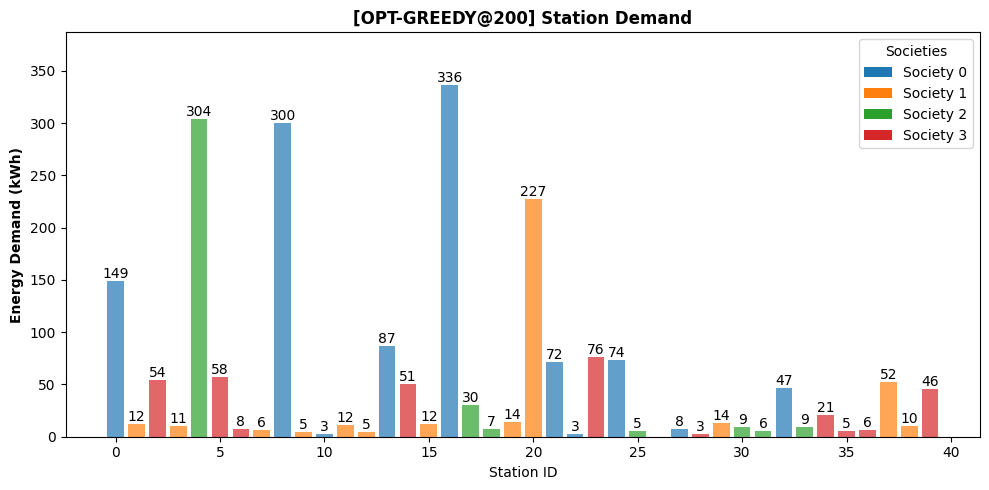

In [118]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

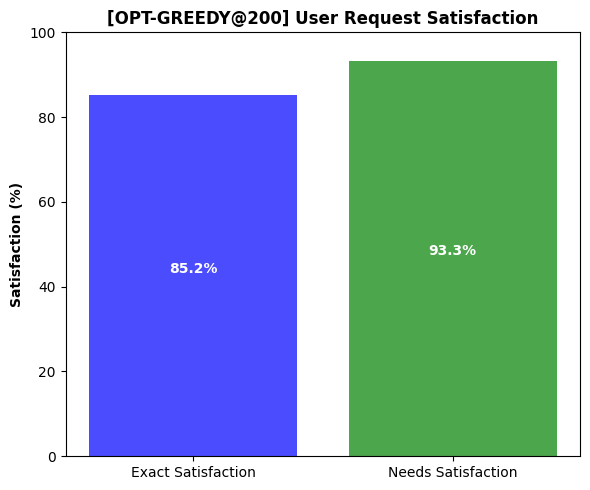

In [119]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

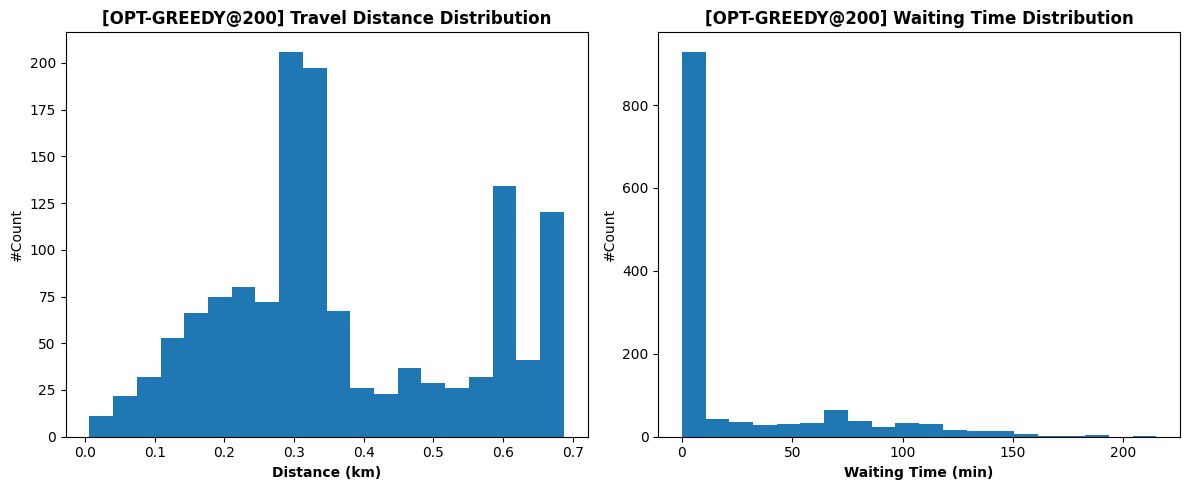

In [120]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

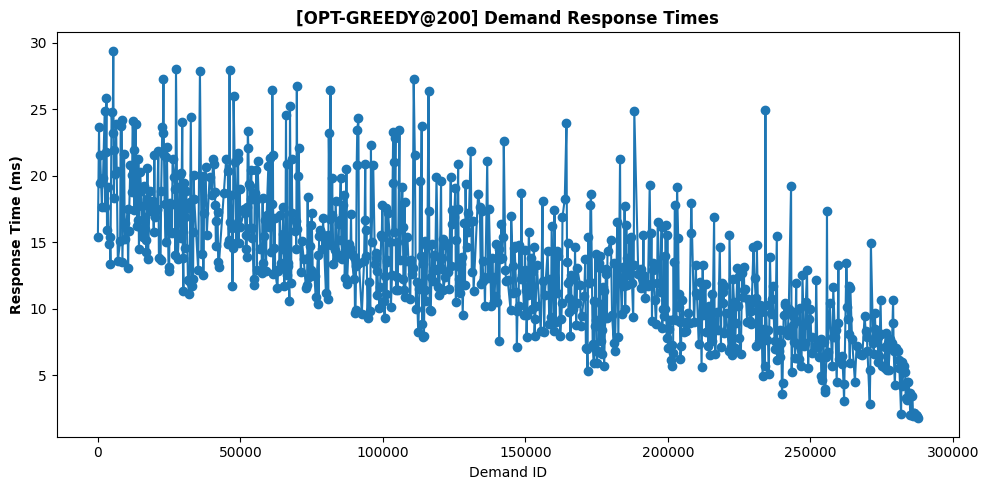

In [121]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

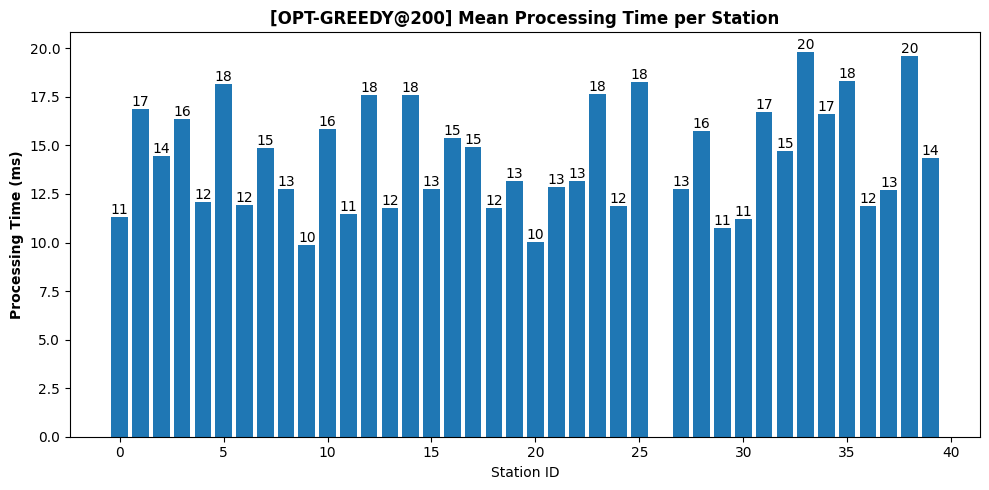

In [122]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [ ]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/bramev/200cars


##### *Initialisation*

In [124]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [125]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:11:10.714 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:11:11.890 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:11:13.196 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:11:15.384 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:11:16.610 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:11:18.541 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:11:20.513 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:11:22.749 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:11:24.645 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:11:25.821 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:11:27.642 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [126]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 7.98 kWh
  Station 1: 49.83 kWh
  Station 2: 18.33 kWh
  Station 3: 9.10 kWh
  Station 4: 30.46 kWh
  Station 5: 0.00 kWh
  Station 6: 49.59 kWh
  Station 7: 47.28 kWh
  Station 8: 54.39 kWh
  Station 9: 22.92 kWh
  Station 10: 2.67 kWh
  Station 11: 88.94 kWh
  Station 12: 21.25 kWh
  Station 13: 22.15 kWh
  Station 14: 5.80 kWh
  Station 15: 80.14 kWh
  Station 16: 9.05 kWh
  Station 17: 66.72 kWh
  Station 18: 45.40 kWh
  Station 19: 16.55 kWh
  Station 20: 6.65 kWh
  Station 21: 4.40 kWh
  Station 22: 229.82 kWh
  Station 23: 25.18 kWh
  Station 24: 19.62 kWh
  Station 25: 98.38 kWh
  Station 26: 26.77 kWh
  Station 27: 36.08 kWh
  Station 28: 161.89 kWh
  Station 29: 15.42 kWh
  Station 30: 53.47 kWh
  Station 31: 104.12 kWh
  Station 32: 165.39 kWh
  Station 33: 100.21 kWh
  Station 34: 12.52 kWh
  Station 35: 102.11 kWh
  Station 36: 10.98 kWh
  Station 37: 211.14 kWh
  Station 38: 119.29 kWh
  Station 3

In [127]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

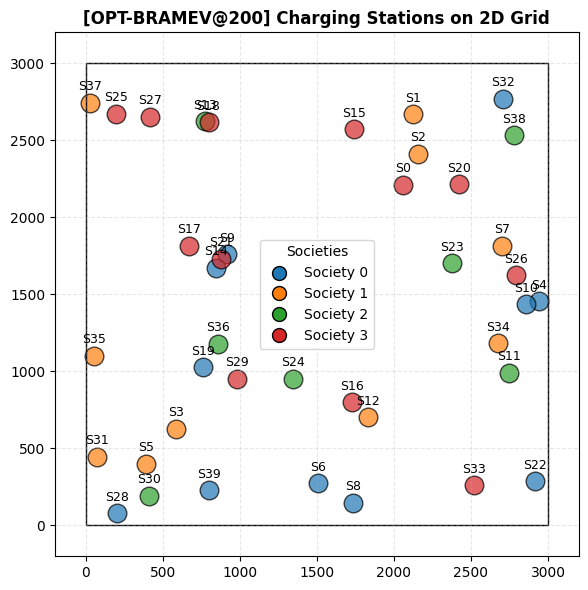

In [128]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

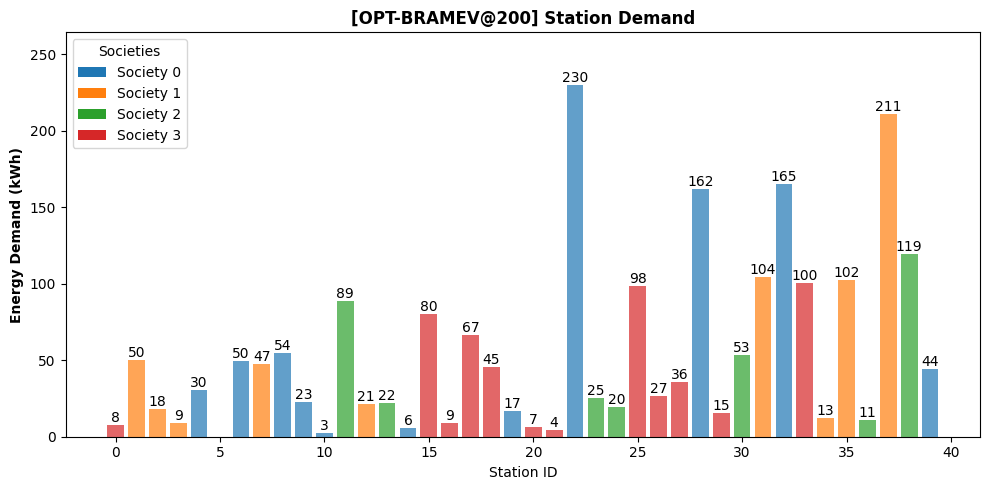

In [129]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

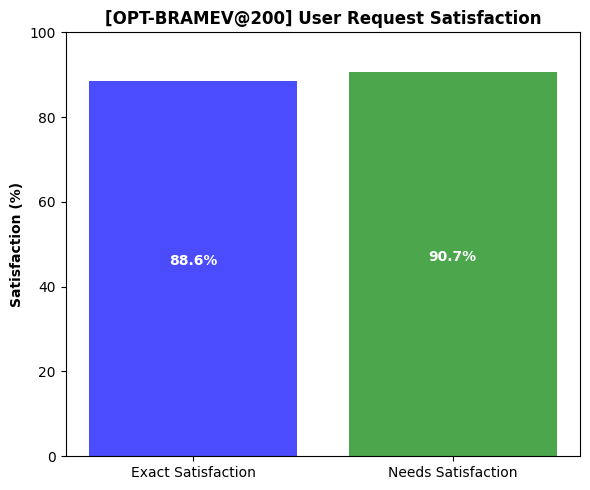

In [130]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

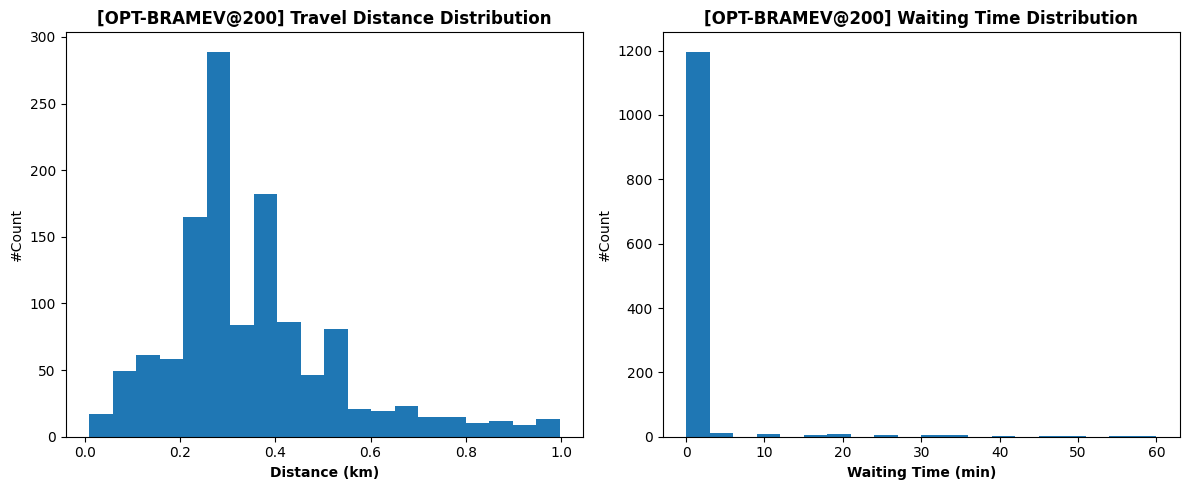

In [131]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

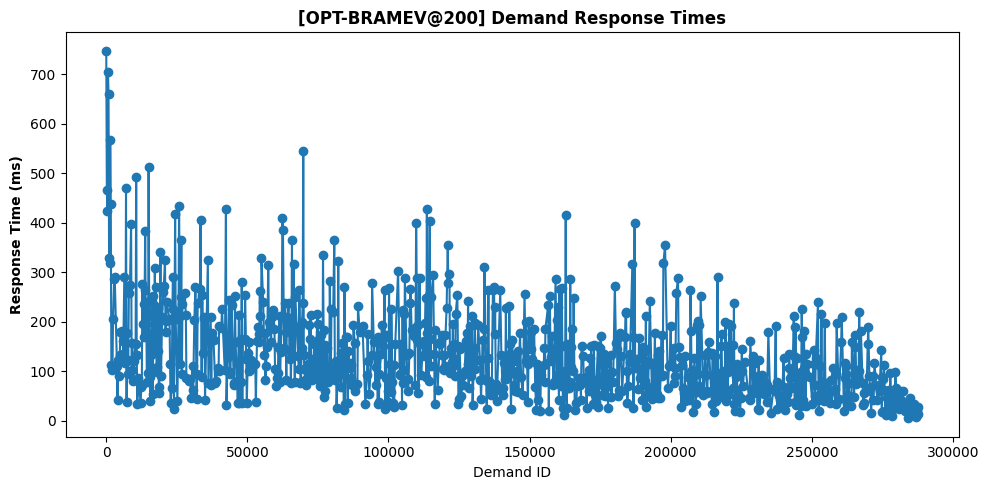

In [132]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

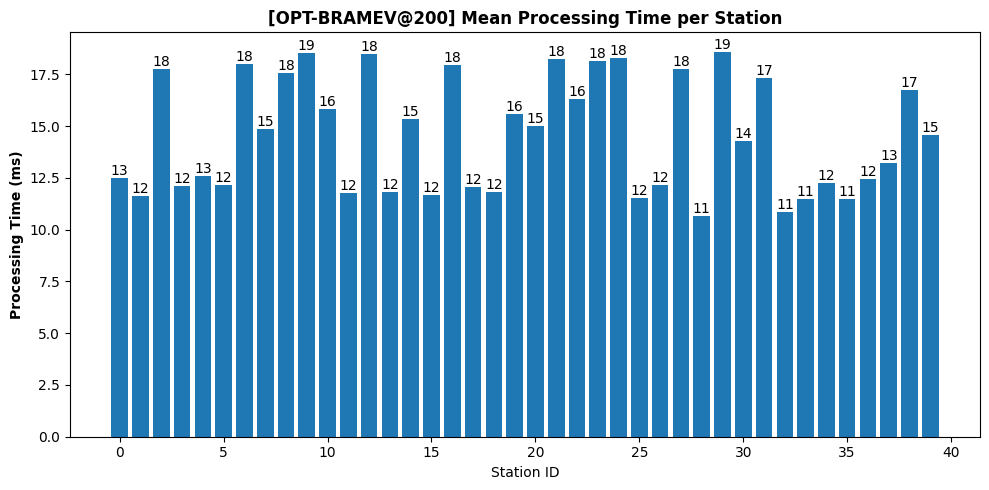

In [133]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

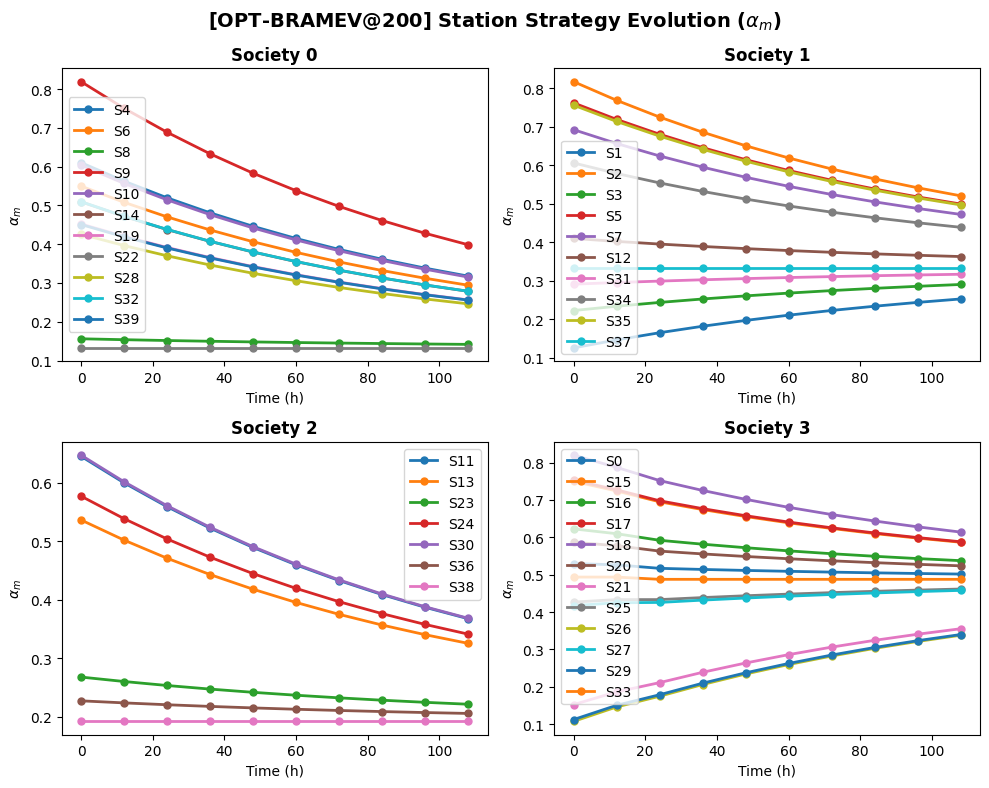

In [134]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [135]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           4  0.261111  0.098611  0.047917  0.000000       NaN   
1            0           6  0.504861  0.205556  0.000000  0.000000  0.000000   
2            0           8  0.386806  0.223611  0.036806  0.073611  0.033333   
3            0           9  0.270139  0.077083  0.000000  0.000000  0.000000   
4            0          10  0.039583  0.000000  0.000000  0.000000  0.000000   
5            0          14  0.103472  0.000000  0.000000  0.000000  0.000000   
6            0          19  0.150000  0.082639  0.000000  0.000000  0.000000   
7            0          22  0.743056  0.722222  0.656250  0.461806  0.370139   
8            0          28  0.742361  0.574306  0.524306  0.570139       NaN   
9            0          32  0.730556  0.646528  0.573611  0.518750       NaN   
10           0          39  0.394444  0.211111  0.000000  0.000000  0.000000   
11           1           1  0.427778  0.

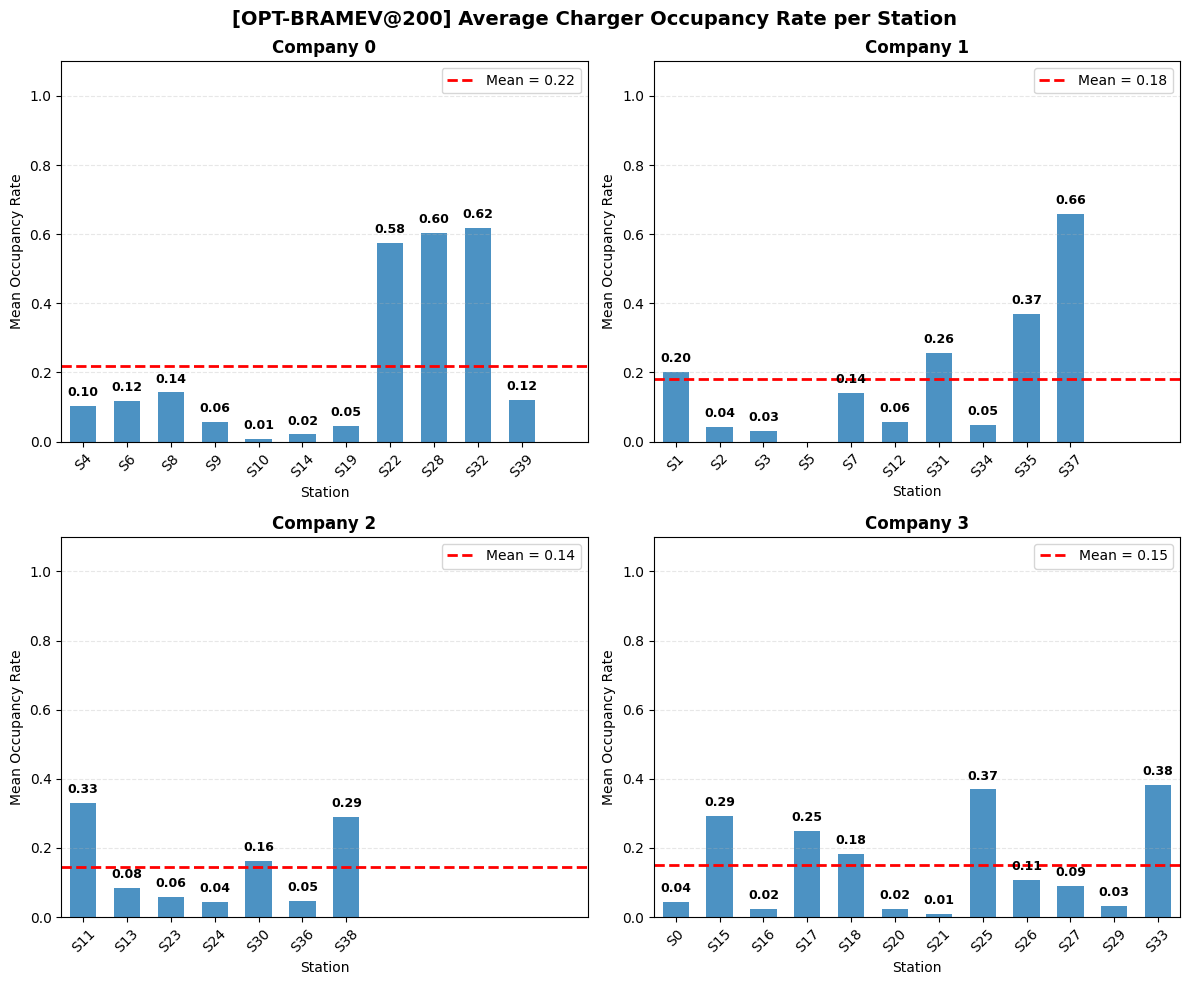

In [136]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

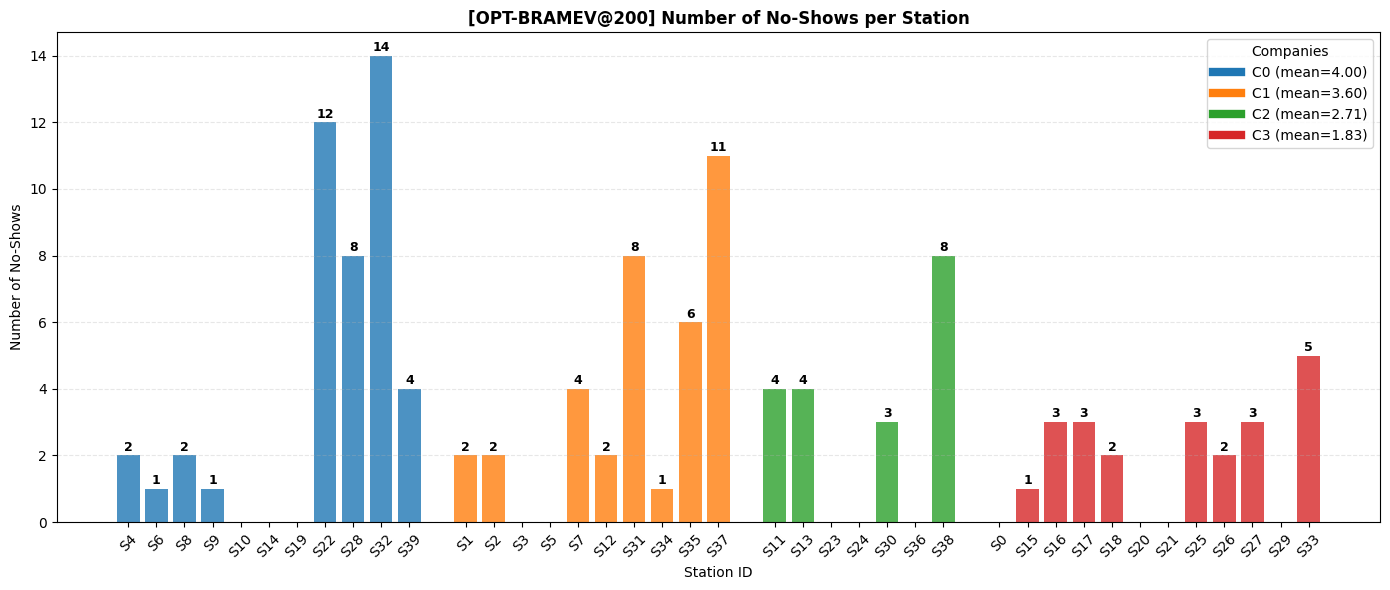

In [137]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [138]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,4,20,17,2,0,0,0.850000,0.100000,0.0,0.0
1,0,6,30,29,1,0,0,0.966667,0.033333,0.0,0.0
2,0,8,34,32,2,0,0,0.941176,0.058824,0.0,0.0
3,0,9,14,13,1,0,0,0.928571,0.071429,0.0,0.0
4,0,10,2,2,0,0,0,1.000000,0.000000,0.0,0.0
5,0,14,3,3,0,0,0,1.000000,0.000000,0.0,0.0
6,0,19,9,9,0,0,0,1.000000,0.000000,0.0,0.0
7,0,22,146,133,12,0,0,0.910959,0.082192,0.0,0.0
8,0,28,102,94,8,0,0,0.921569,0.078431,0.0,0.0
9,0,32,104,90,14,0,0,0.865385,0.134615,0.0,0.0


#### **COMPARISON**

##### *Params*

In [139]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

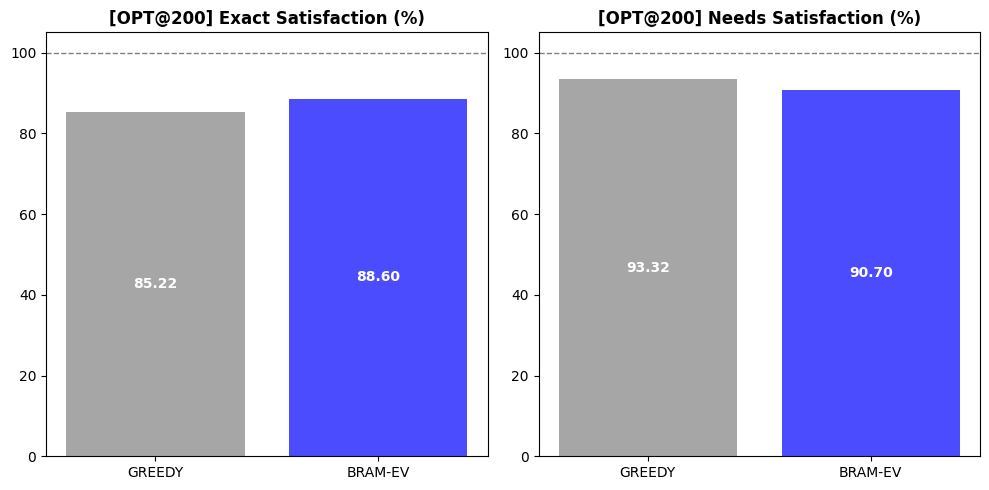

In [140]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

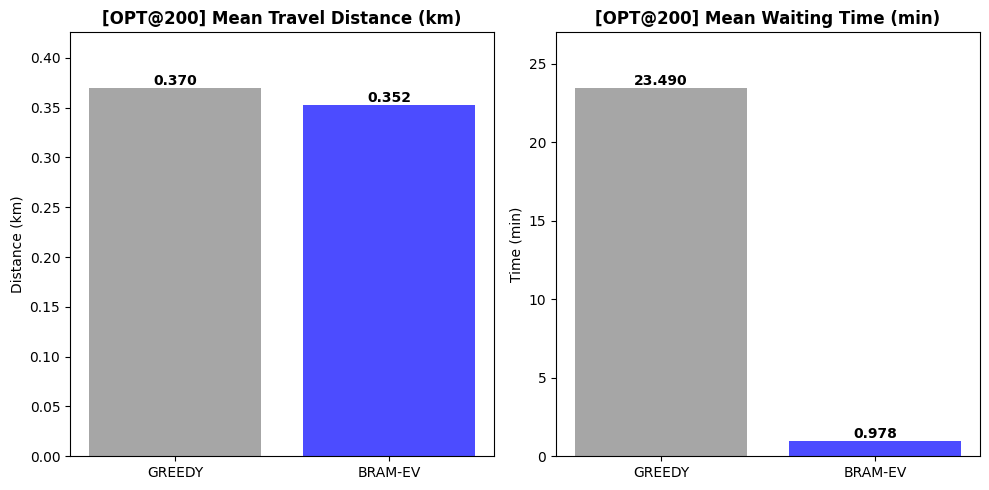

In [141]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

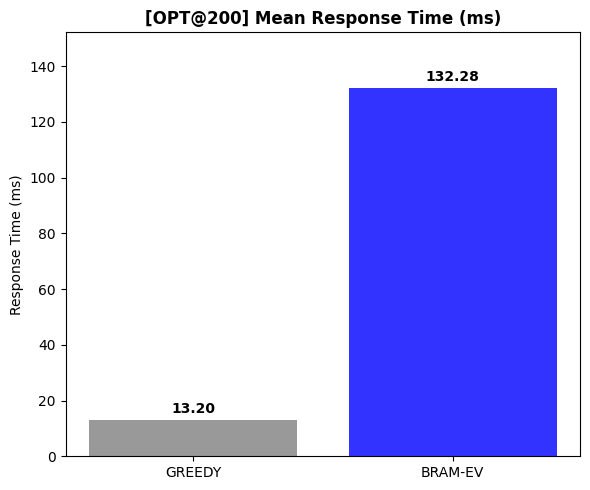

In [142]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [143]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [144]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/optimistic/greedy/250cars


##### *Initialisation*

In [145]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [146]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:13:14.875 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:13:15.201 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:13:15.513 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:13:15.805 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:13:16.149 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:13:16.328 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:13:16.706 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:13:16.965 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:13:17.398 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:13:17.701 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:13:18.104 | IN

##### *Metrics*

In [147]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 318.14 kWh
  Station 1: 15.76 kWh
  Station 2: 82.33 kWh
  Station 3: 121.85 kWh
  Station 4: 30.13 kWh
  Station 5: 125.08 kWh
  Station 6: 8.93 kWh
  Station 7: 26.51 kWh
  Station 8: 5.39 kWh
  Station 9: 111.61 kWh
  Station 10: 5.32 kWh
  Station 11: 8.50 kWh
  Station 12: 10.29 kWh
  Station 13: 33.74 kWh
  Station 14: 4.57 kWh
  Station 15: 95.12 kWh
  Station 16: 7.05 kWh
  Station 17: 20.23 kWh
  Station 18: 111.69 kWh
  Station 19: 18.00 kWh
  Station 20: 13.87 kWh
  Station 21: 4.92 kWh
  Station 22: 297.27 kWh
  Station 23: 30.63 kWh
  Station 24: 13.76 kWh
  Station 25: 12.38 kWh
  Station 26: 19.80 kWh
  Station 27: 45.74 kWh
  Station 28: 8.35 kWh
  Station 29: 122.82 kWh
  Station 30: 74.21 kWh
  Station 31: 17.36 kWh
  Station 32: 1.75 kWh
  Station 33: 52.71 kWh
  Station 34: 34.23 kWh
  Station 35: 334.25 kWh
  Station 36: 13.80 kWh
  Station 37: 324.56 kWh
  Station 38: 3.35 kWh
  Station 39

In [148]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

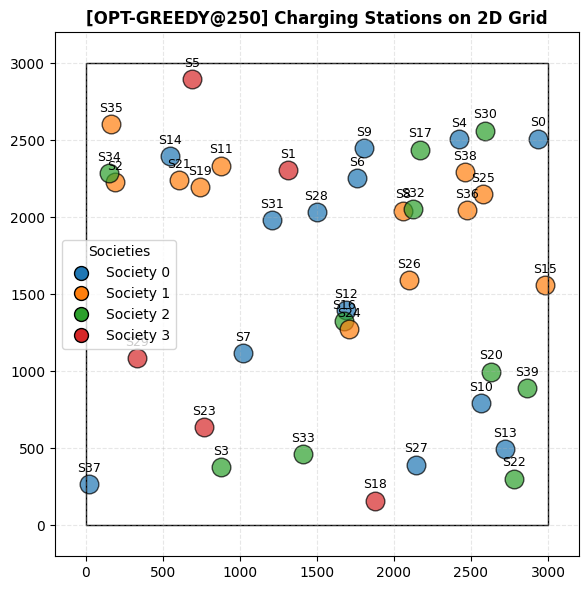

In [149]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

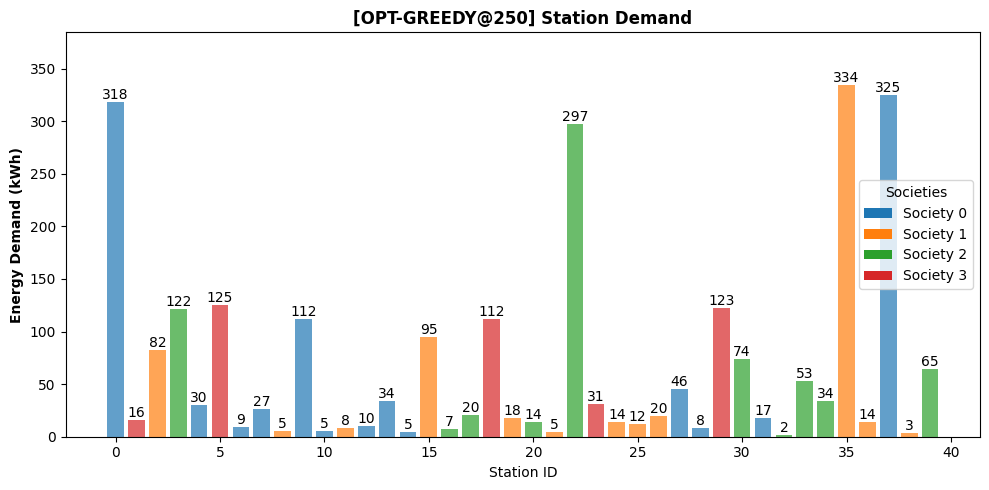

In [150]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

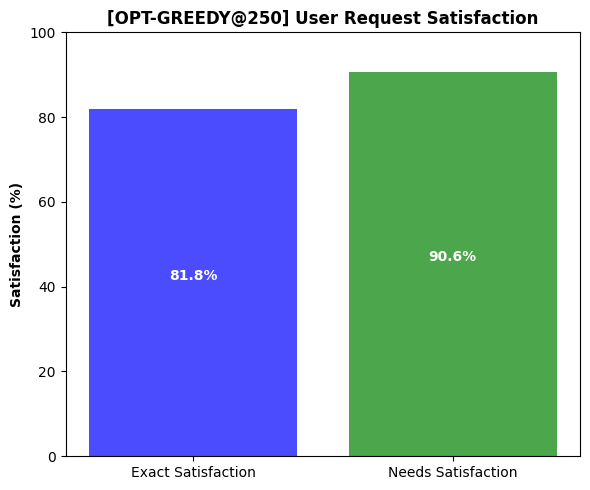

In [151]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

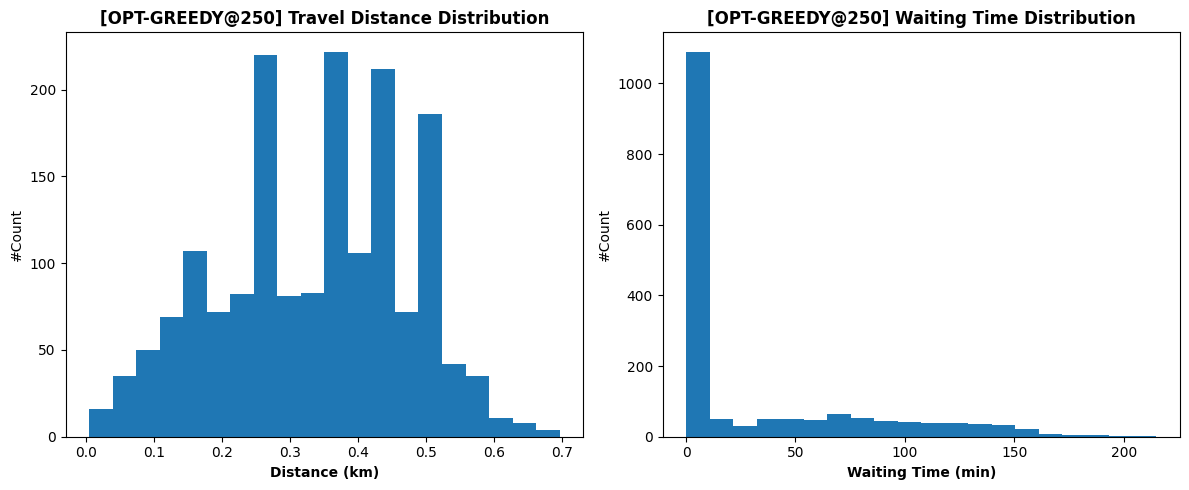

In [152]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

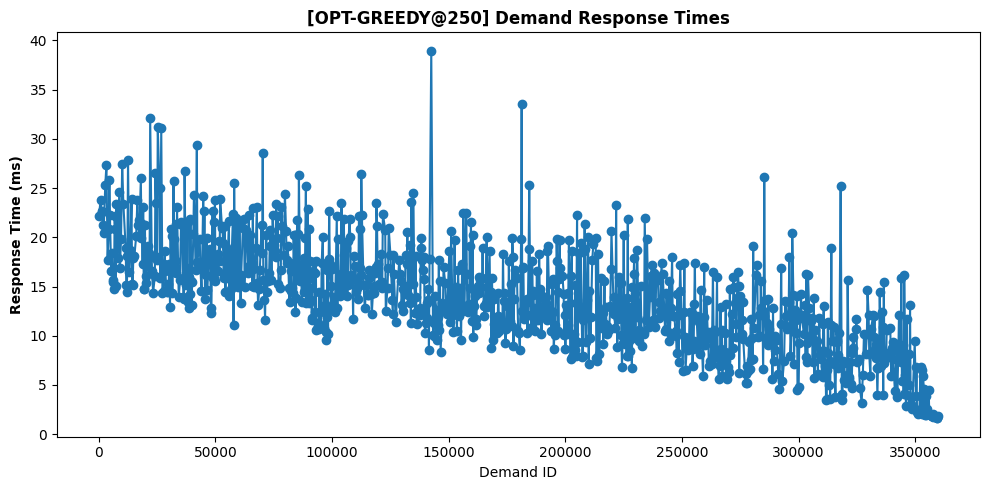

In [153]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

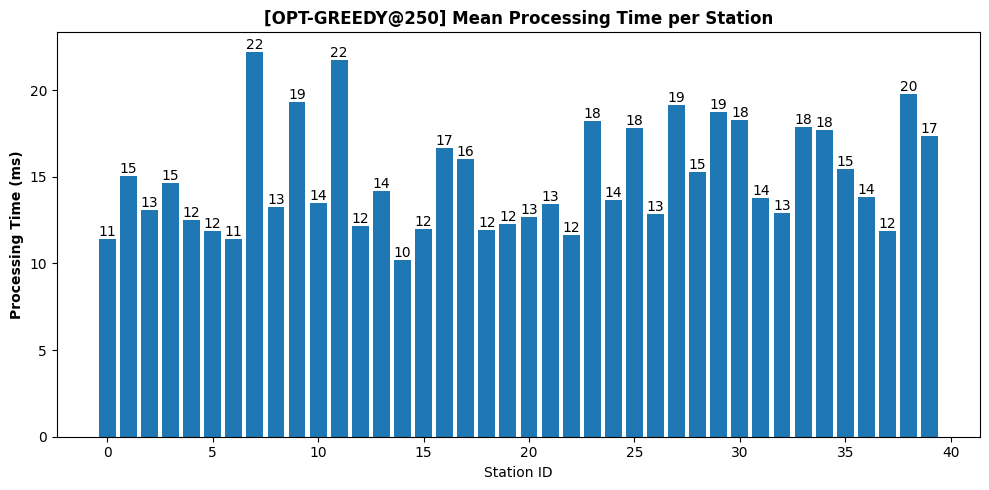

In [154]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [155]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [156]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [157]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:13:49.828 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:13:54.879 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:13:56.814 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:13:58.174 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:13:59.965 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:14:02.604 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:14:05.482 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:14:07.486 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:14:09.029 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:14:11.324 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:14:12.847 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [158]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 17.27 kWh
  Station 1: 15.91 kWh
  Station 2: 75.81 kWh
  Station 3: 8.46 kWh
  Station 4: 250.33 kWh
  Station 5: 31.00 kWh
  Station 6: 7.45 kWh
  Station 7: 82.97 kWh
  Station 8: 17.52 kWh
  Station 9: 119.17 kWh
  Station 10: 22.55 kWh
  Station 11: 101.08 kWh
  Station 12: 19.41 kWh
  Station 13: 107.56 kWh
  Station 14: 5.50 kWh
  Station 15: 28.02 kWh
  Station 16: 25.07 kWh
  Station 17: 41.98 kWh
  Station 18: 41.43 kWh
  Station 19: 96.31 kWh
  Station 20: 24.00 kWh
  Station 21: 21.77 kWh
  Station 22: 33.63 kWh
  Station 23: 17.56 kWh
  Station 24: 18.40 kWh
  Station 25: 111.57 kWh
  Station 26: 16.21 kWh
  Station 27: 75.89 kWh
  Station 28: 82.94 kWh
  Station 29: 162.82 kWh
  Station 30: 15.32 kWh
  Station 31: 253.31 kWh
  Station 32: 17.33 kWh
  Station 33: 272.18 kWh
  Station 34: 10.68 kWh
  Station 35: 36.38 kWh
  Station 36: 240.82 kWh
  Station 37: 61.10 kWh
  Station 38: 102.97 kWh
  St

In [159]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

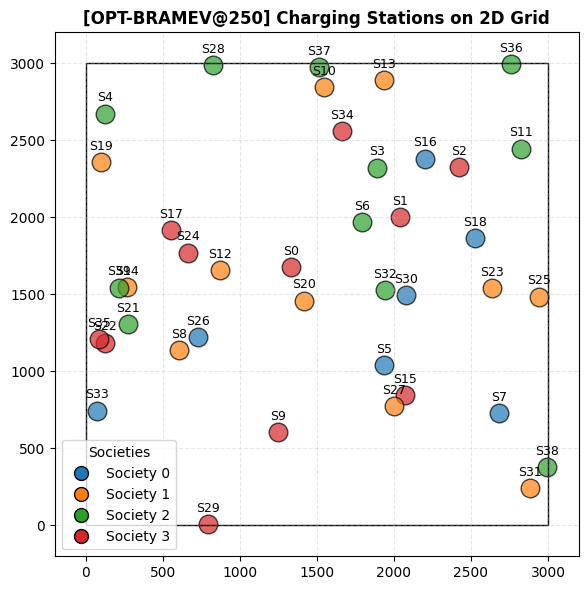

In [160]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

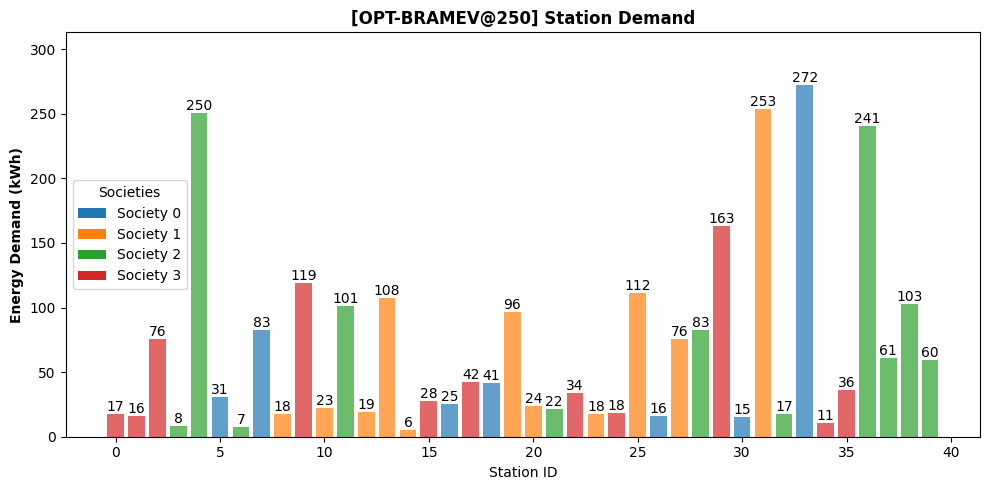

In [161]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

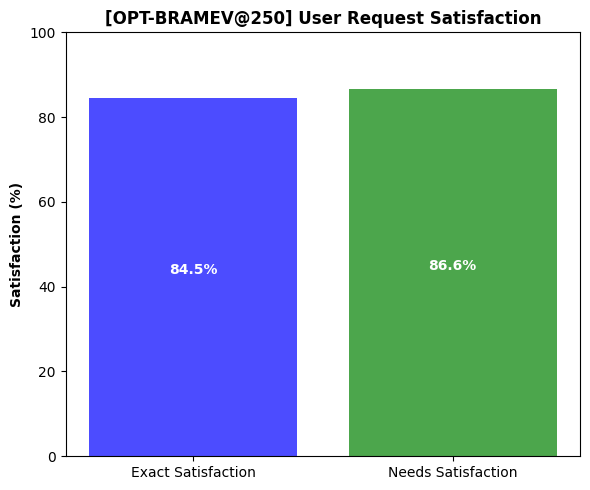

In [162]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

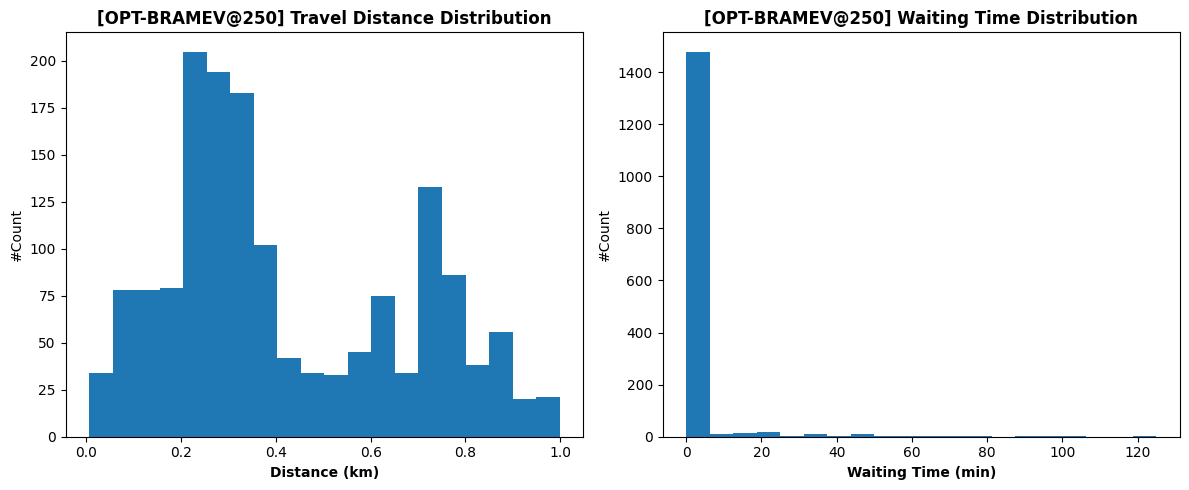

In [163]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

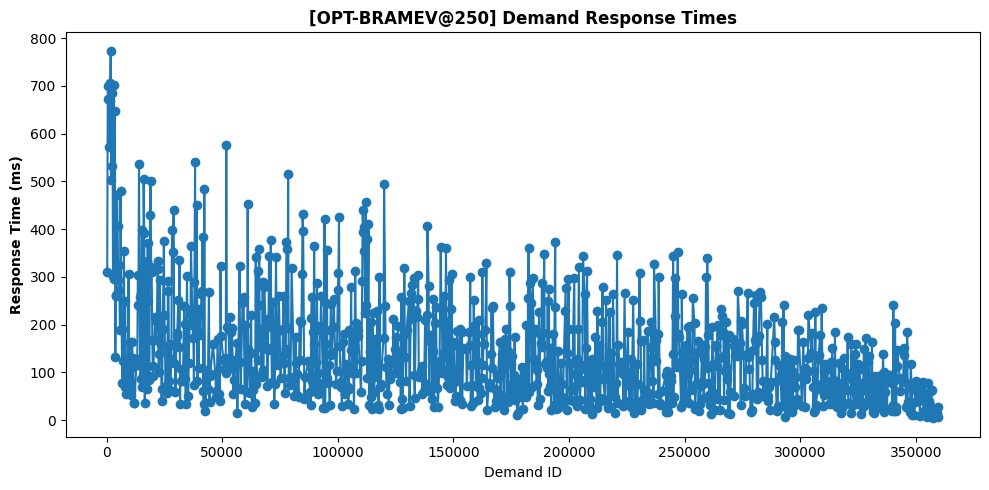

In [164]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

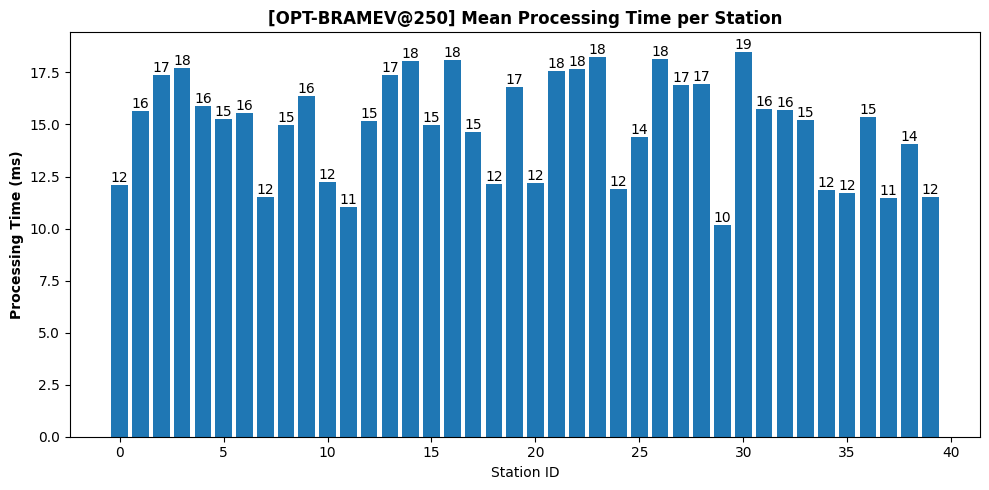

In [165]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

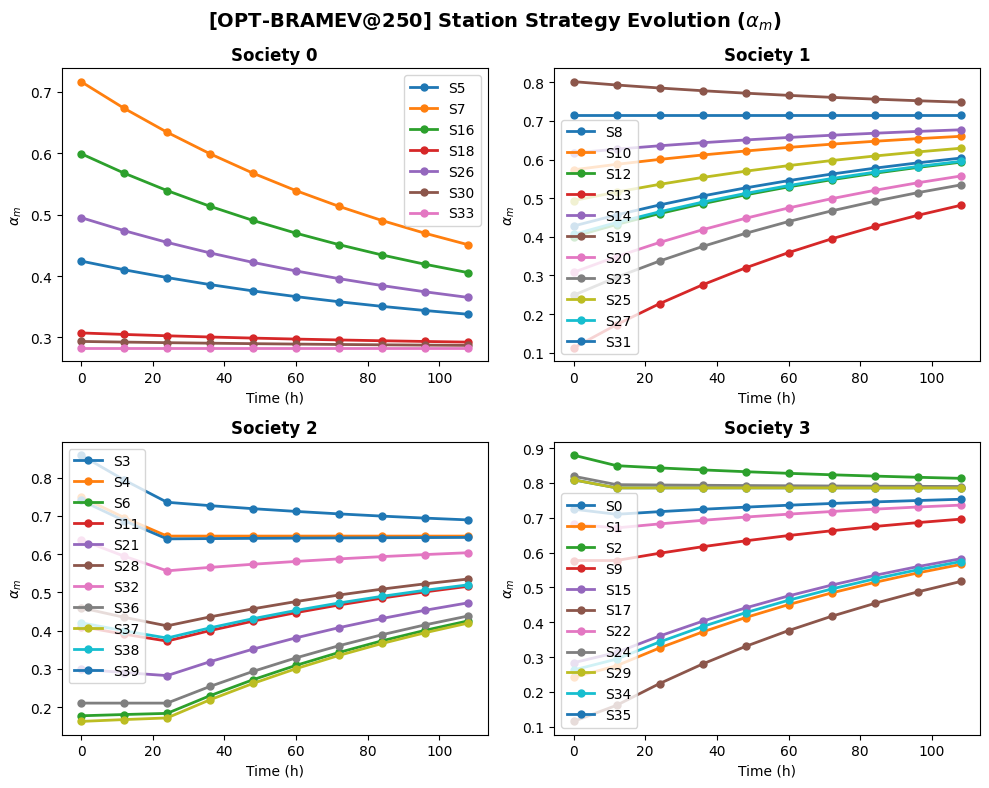

In [166]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [167]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           5  0.254167  0.128472  0.000000  0.039583  0.061111   
1            0           7  0.497917  0.354861  0.159028  0.200694       NaN   
2            0          16  0.250694  0.077778  0.000000  0.000000  0.000000   
3            0          18  0.326389  0.203472  0.027083  0.058333       NaN   
4            0          26  0.235417  0.000000  0.000000  0.000000  0.000000   
5            0          30  0.136806  0.072917  0.000000  0.000000  0.000000   
6            0          33  0.820833  0.825694  0.475694  0.516667  0.568750   
7            1           8  0.229861  0.031944  0.000000  0.000000  0.000000   
8            1          10  0.284722  0.061111  0.000000  0.000000       NaN   
9            1          12  0.238194  0.022917  0.000000  0.000000  0.000000   
10           1          13  0.679861  0.404861  0.157639  0.052083  0.000000   
11           1          14  0.046528  0.

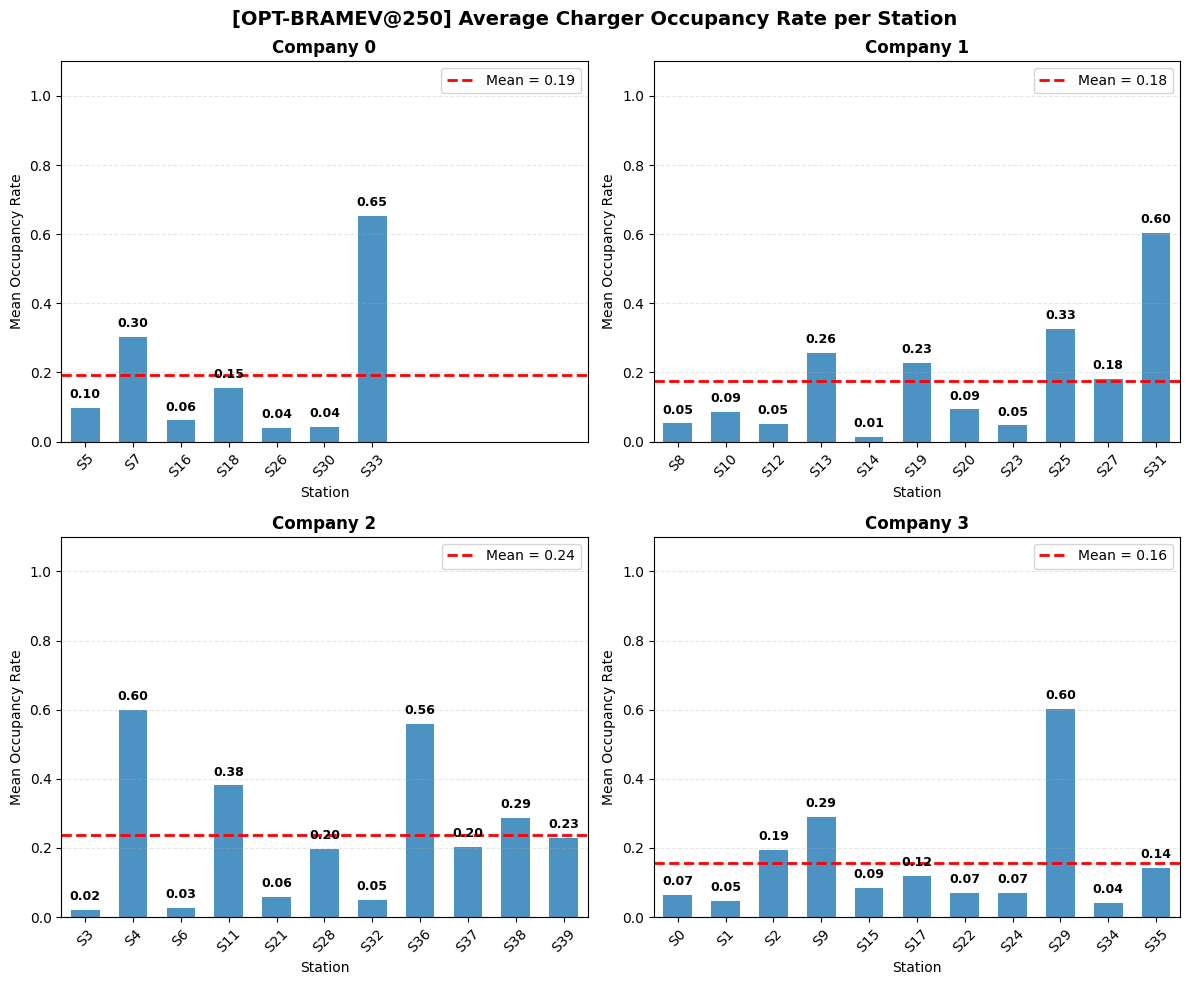

In [168]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

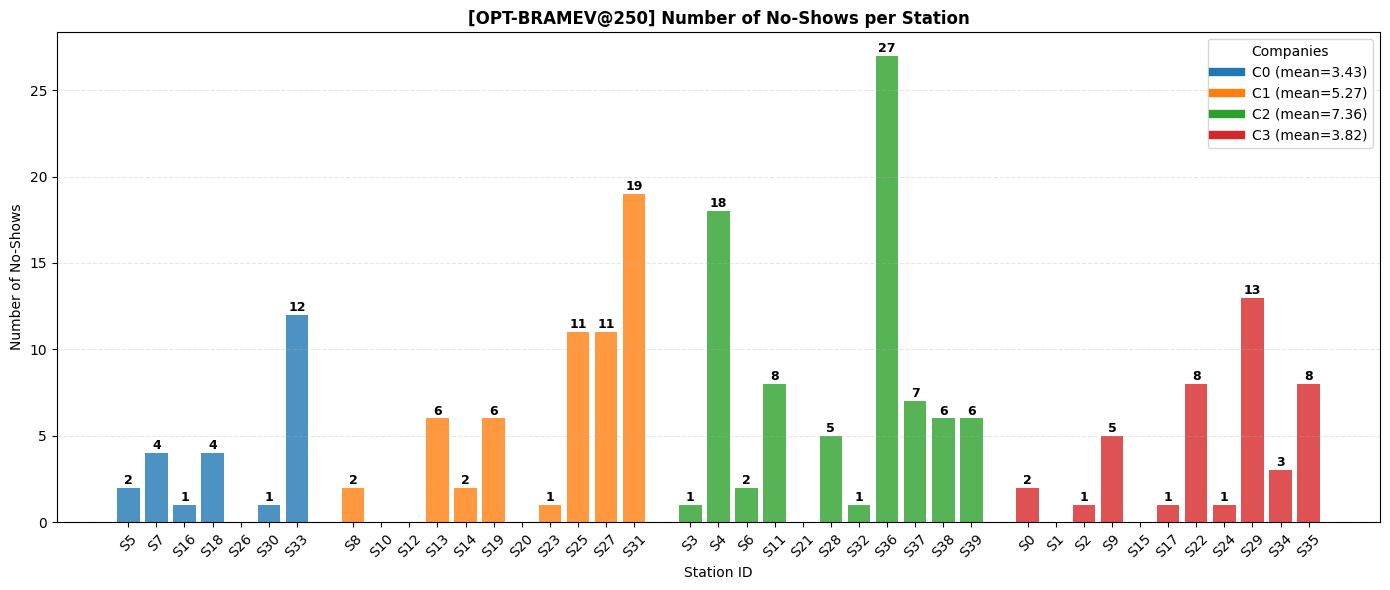

In [169]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [170]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,5,19,17,2,0,0,0.894737,0.105263,0.0,0.0
1,0,7,52,48,4,0,0,0.923077,0.076923,0.0,0.0
2,0,16,15,14,1,0,0,0.933333,0.066667,0.0,0.0
3,0,18,27,23,4,0,0,0.851852,0.148148,0.0,0.0
4,0,26,10,9,0,0,0,0.900000,0.000000,0.0,0.0
5,0,30,9,8,1,0,0,0.888889,0.111111,0.0,0.0
6,0,33,169,156,12,0,0,0.923077,0.071006,0.0,0.0
7,1,8,14,12,2,0,0,0.857143,0.142857,0.0,0.0
8,1,10,12,12,0,0,0,1.000000,0.000000,0.0,0.0
9,1,12,10,10,0,0,0,1.000000,0.000000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [171]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

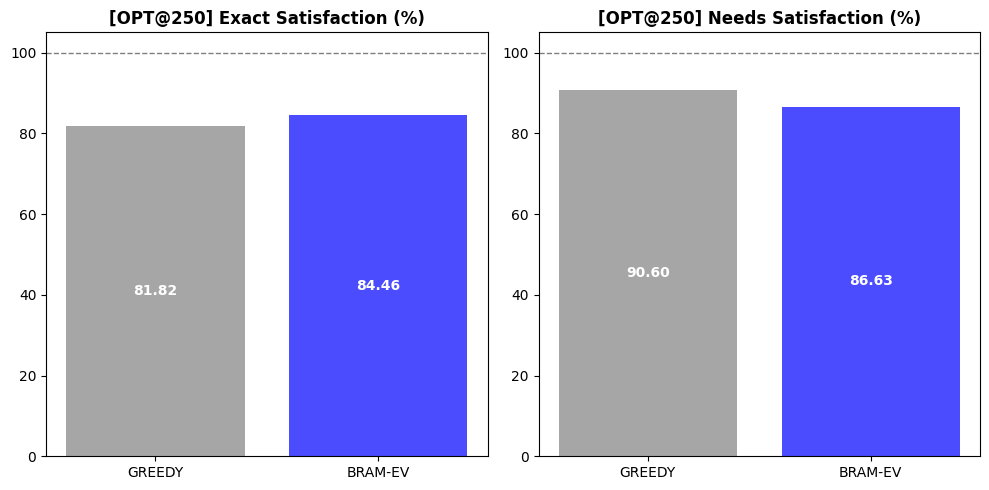

In [172]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

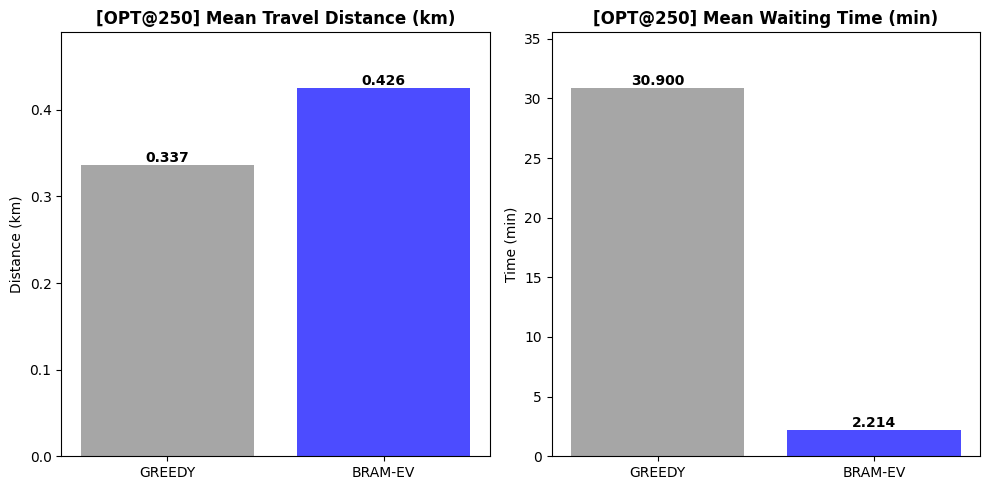

In [173]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

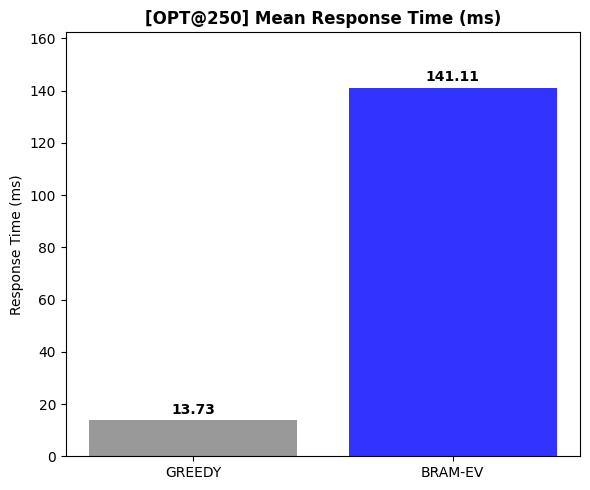

In [174]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

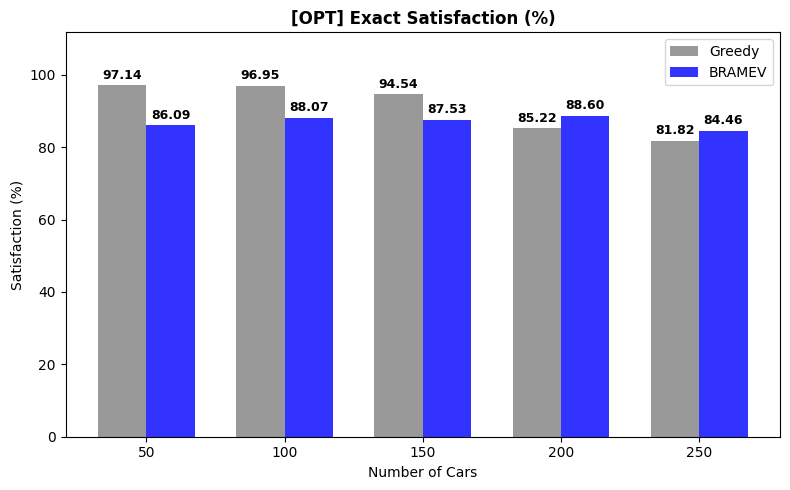

In [175]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

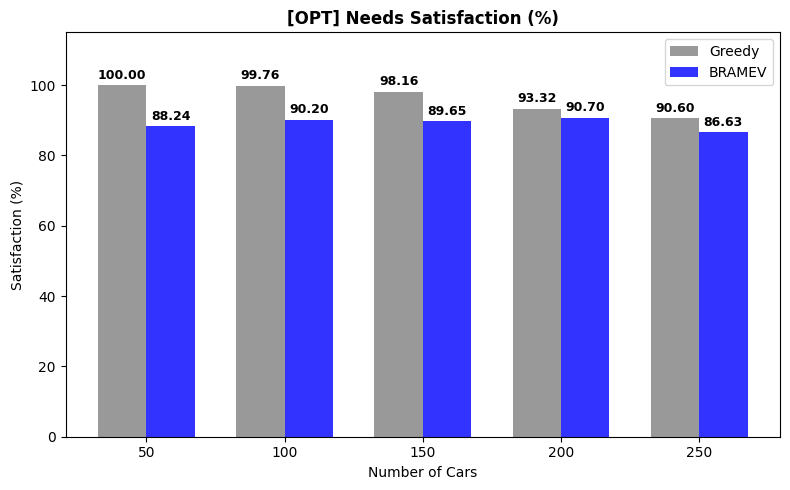

In [176]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

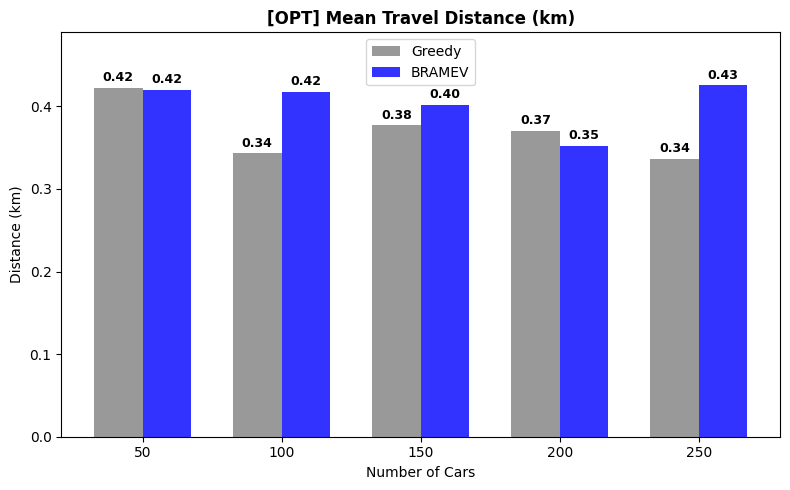

In [177]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


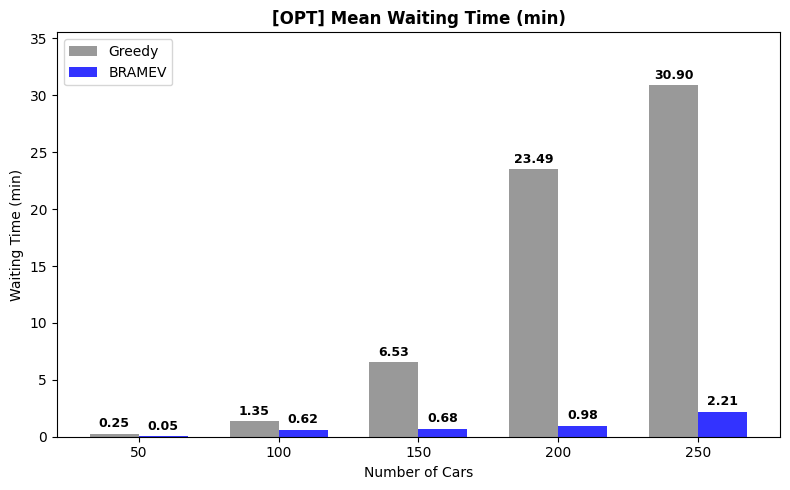

In [178]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


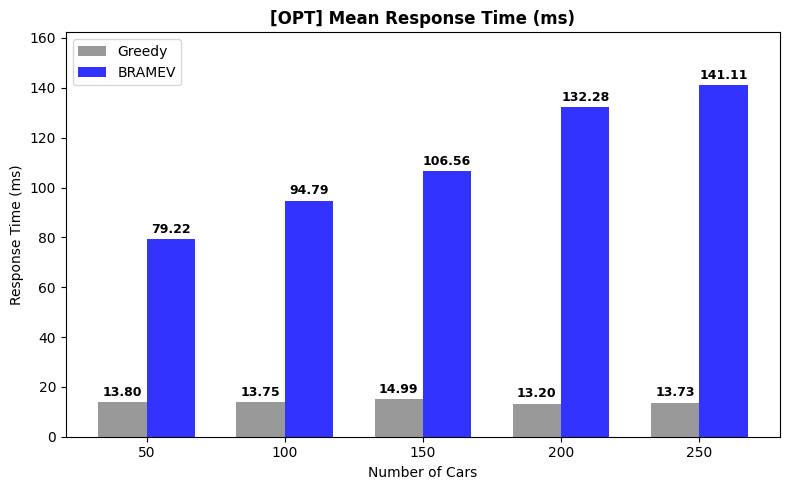

In [179]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
